# Домашнее задание №2
Текстовая аналитика

## Часть 1. Анализ текстов песен 
Для начала устанавливаем необходимые библиотеки:
- `nltk` — для работы со стоп-словами и токенизацией
- `pymorphy3` — для лемматизации русского языка
- `wordcloud` — для визуализации текста
- `scikit-learn` — для расчета TF-IDF

In [2]:
!pip install nltk pymorphy3 wordcloud gensim scikit-learn 
!python -m spacy download ru_core_news_sm

zsh:1: command not found: python


Импортируем необходимые библиотеки:
- `time` - для замера времени выполнения метода 
- `re` - для очистки текста с помощью регулярных выражений
- `string` - для удаления знаков пунктуации
- `pymorphy3` - для леммантизации
- `ntkl` - для удаления стоп-слов  
- `stopwords` - список стоп-слов
- `word_tokenize` - для токенизации текста
- `TfidfVectorizer` -  для вычисления TF-IDF 

In [3]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy import stats
from IPython.display import display 

import time 
import re
import string
import pymorphy3
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

Загружаем ресурсы nltk:
- `punkt` - для токенизации текста 
- `stopwords` - список стоп-слов

In [4]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /Users/user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/user/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Выводим все колонки и строки таблицы

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

Не показываем предупреждения

In [6]:
import warnings
warnings.filterwarnings('ignore')

Записываем тексты трех песен на русском языке: 
- Женя Трофимов & Комната культуры - "Поезда"
- Beautiful Boys - "Ниоткуда с любовью"
- Basta, HammAli & Navai - "Эта песня твоя бессонница"

In [7]:
song_1 = '''
Тяни лотерейный билет
Чтоб тамбур прокуренным был
У нас с тобой выигравших нет
Лишь бы просто дорогу к тебе не забыл, и
Стаканов гранёных шум
Трещит, как любовь, по швам
Я каждый вокзал прошу:
«Не пускай меня к поездам»
И рельсы — сердечный пульс
Железные струны души
Наверное, скоро вернусь
Ты, пожалуйста, только пиши мне
И тянутся города
Я в каждом из них бывал
Нас ссорили поезда
Но мирил нас пустой вокзал
Чтоб быть с тобой навсегда
Я сразу билеты взял
Нас ссорили поезда
Но мирил нас пустой вокзал
Меняется в окнах день
Зачеркнутый в календаре
Проводницам здороваться лень
Но сейчас они главные в нашей судьбе, и
Пестрят заголовки газет
Что против судьбы не пойдёшь
Любви в этом городе нет
Но я знаю, что ты меня ждёшь
'''

In [8]:
song_2 = '''
Я забыл, что значит ночь
Я забыл, что значит сон
Я забыл тебя совсем
Я устал от всех речей
Ты исчезла в небытии
Ты застыла в синеве
Я — ничто, а ты нигде
Где мне скрыть свою печаль?
В воскресенье будет дождь
Переулки захрипят
А в душе моей больной
Снова кошки заскрипят
Ты застыла в синеве
Я руками резал нить
Окунусь в вино, как в чай
Где мне скрыть свою печаль?
Ниоткуда с любовью
Ты напишешь мне снова
И настанет день новый
День, в котором
Мы останемся дома
Ниоткуда с любовью
Ты напишешь мне снова
И настанет день новый
День, в котором
Мы останемся дома
У-у-у
Мы останемся дома
У-у-у
Ниоткуда с любовью
Лучше спичкой сгореть
Чем всю жизнь отдать тебе
Стать лишь тенью от часов
Или лаем твоих псов
В ветре тает огонёк
Это писем всех итог
Город слушает меня
Но не разбирает слов
'''

In [9]:
song_3 = '''
И то, что было между нами, теперь спрятано во тьме
Я кричу тебе: «Прости меня», но тишина в ответ
Если можно было бы всё отмотать и не болеть
Я бы заново тобою заболел, чтобы умереть
Мрачный квартал, на фоне репчик про любовь
Горит огнём район, бесконечный марафон
Район кричал: «Остановись, тебе с ней не по пути»
Я в ответ ему кричал: «Ну попробуй запрети»
Район кричал: «Остановись, она тебе не по зубам»
Но я сказал: «Она будет моей» и я ответил за базар
Мой мир рушился из-за неё, у всех на глазах
Рушился и я не хотел его спасать
На кухне разговор на повышенных тонах
И наверно ты права, делать тебе больно — мой главный талант
И я с тобой прощаюсь, эта песенка спета
А для тебя останусь болью на рассвете
Эта песня твоя бессонница, то что забыто, навсегда сегодня вспомнится
И до утра ты не успокоишься, а на рассвете уснёшь не с тем
Где ты теперь и с кем? Где ты теперь и с кем?
Счастлива с ним, но вспоминаешь наш рассвет
Где ты теперь и с кем? Где ты теперь и с кем?
Видишь меня во сне, но это наш секрет
С тобою или без, я всё равно дотянусь до небес
Я не герой из песен, знаю сколько стоит этот блеск
Разговоры по душам, к чёрту это всё
Видимо любовь ушла, а срок истёк
Как жаль, но как же круто вспоминать тебя ежеминутно в нашей пустой квартире
Пожар и тебе будет трудно вернуть то, что было главным в нашем идеальном мире
На Патриках веселье, к чёрту эту суету, я наболтаю этот трек и им заполню пустоту
И ты услышишь в этих строках голос мой, и эта песня — тебе письмо
Что, кроме любви, творит большие чудеса?
Исцеляет вдребезги разбитые сердца
До тебя не верил сам и обращаюсь к небесам
Я молился за тебя, а после снова о тебе писал
Если спросят про боль мою и в чём причина
Я, не задумываясь, назову им твоё имя
Я в четырёх стенах, тишина пустой квартиры
Мы лишнего наговорили
Твой маяк — рой безвольных истерик
И невольно я вдохновляюсь не теми
Позже боль моя будет услышана всеми
Услышана всеми, но только не тобой
Да, я странный тип, мне надо совсем немного
За твоё счастье по ночам я обращался к Богу
Ты, не зная, как любить, забрала свободу
И я боль свою запомню
'''

Создаем список песен для дальнейшей обработки 

In [10]:
songs = [song_1, song_2, song_3]

### Преобразовываем тексты песен
- переводим все слова в нижний регистр 
- удаляем переносы и знаки пунктуации
- делаем токенизацию 
- удаляем стоп-слова
- делаем леммантизацию 

Так как в списке стоп-слов приведены слова в разных формах, то мы сначала удаляем их, а уже потом делаем леммантизацию.

In [11]:
stop_words = set(stopwords.words("russian"))

`Леммантизация` - приведение слов к начальной форме. `Стемминг` - отбрасывание окончаний слов. 

In [12]:
morph = pymorphy3.MorphAnalyzer()

`Токенизация` - разбиение текста на мелкие смысловые единицы (токены).

In [13]:
def preprocess_text(text):
    # Приводим текст к нижнему регистру
    text = text.lower()

    # Удаляем переносы строк
    text = re.sub(r"\n", " ", text)

    # Удаляем знаки пунктуации
    text = text.translate(str.maketrans('', '', string.punctuation + "«»—"))

    # Токенизация
    tokens = word_tokenize(text)

    clean_tokens = []

    for token in tokens:
        if token.isalpha():
            # Пропускаем токен, если он есть в стоп-словах
            if token in stop_words:
                continue
                
            # Лемматизация
            lemma = morph.parse(token)[0].normal_form
            
            # Пропускаем лемму, если она есть в стоп-словах
            if lemma in stop_words:
                continue
                
            clean_tokens.append(lemma)

    return " ".join(clean_tokens)

In [14]:
processed_songs = [preprocess_text(song) for song in songs]

Дополнительно убираем стоп-слова, которых нет в словаре

In [15]:
def remove_stopwords_regex(text, words_to_remove):
    pattern = r'\b(?:' + '|'.join(re.escape(word) for word in words_to_remove) + r')\b'
    
    # Удаляем слова и лишние пробелы
    text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text) 
    return text.strip()

stop_words_to_remove = ['лишь', 'наш', 'который', 'ууу', 'твой', 'это', 'изз', 'всё', 'весь']

processed_songs = [remove_stopwords_regex(preprocess_text(song), stop_words_to_remove) 
                   for song in songs]

Смотрим результат обработки текстов

In [16]:
for i, song in enumerate(processed_songs):
    print(f"Песня {i+1}:")
    print(song)
    print()

Песня 1:
тянуть лотерейный билет тамбур прокурить выиграть просто дорога забыть стакан гранёный шум трещать любовь шов каждый вокзал просить пускай поезд рельс сердечный пульс железный струна душа наверное скоро вернуться пожалуйста писать тянуться город каждый бывать ссорить поезд мирить пустой вокзал навсегда сразу билет взять ссорить поезд мирить пустой вокзал меняться окно день зачеркнуть календарь проводница здороваться лень главный судьба пестрить заголовок газета против судьба пойти любовь город знать ждать

Песня 2:
забыть значит ночь забыть значит сон забыть устать речь исчезнуть небытие застылый синева ничто нигде скрыть печаль воскресение дождь переулок захрипеть душа больной снова кошка заскрипеть застылый синева рука резать нить окунуться вино чай скрыть печаль ниоткуда любовь написать снова настать день новый день остаться дом ниоткуда любовь написать снова настать день новый день остаться дом остаться дом ниоткуда любовь спичка сгореть жизнь отдать стать тень час лай пёс

In [17]:
pd.set_option('display.max_colwidth', None)

In [18]:
df_comparison = pd.DataFrame({
    "Оригинальный текст": songs,
    "Обработанный текст": processed_songs
})
df_comparison

,Оригинальный текст,Обработанный текст
0,"\nТяни лотерейный билет\nЧтоб тамбур прокуренным был\nУ нас с тобой выигравших нет\nЛишь бы просто дорогу к тебе не забыл, и\nСтаканов гранёных шум\nТрещит, как любовь, по швам\nЯ каждый вокзал прошу:\n«Не пускай меня к поездам»\nИ рельсы — сердечный пульс\nЖелезные струны души\nНаверное, скоро вернусь\nТы, пожалуйста, только пиши мне\nИ тянутся города\nЯ в каждом из них бывал\nНас ссорили поезда\nНо мирил нас пустой вокзал\nЧтоб быть с тобой навсегда\nЯ сразу билеты взял\nНас ссорили поезда\nНо мирил нас пустой вокзал\nМеняется в окнах день\nЗачеркнутый в календаре\nПроводницам здороваться лень\nНо сейчас они главные в нашей судьбе, и\nПестрят заголовки газет\nЧто против судьбы не пойдёшь\nЛюбви в этом городе нет\nНо я знаю, что ты меня ждёшь\n",тянуть лотерейный билет тамбур прокурить выиграть просто дорога забыть стакан гранёный шум трещать любовь шов каждый вокзал просить пускай поезд рельс сердечный пульс железный струна душа наверное скоро вернуться пожалуйста писать тянуться город каждый бывать ссорить поезд мирить пустой вокзал навсегда сразу билет взять ссорить поезд мирить пустой вокзал меняться окно день зачеркнуть календарь проводница здороваться лень главный судьба пестрить заголовок газета против судьба пойти любовь город знать ждать
1,"\nЯ забыл, что значит ночь\nЯ забыл, что значит сон\nЯ забыл тебя совсем\nЯ устал от всех речей\nТы исчезла в небытии\nТы застыла в синеве\nЯ — ничто, а ты нигде\nГде мне скрыть свою печаль?\nВ воскресенье будет дождь\nПереулки захрипят\nА в душе моей больной\nСнова кошки заскрипят\nТы застыла в синеве\nЯ руками резал нить\nОкунусь в вино, как в чай\nГде мне скрыть свою печаль?\nНиоткуда с любовью\nТы напишешь мне снова\nИ настанет день новый\nДень, в котором\nМы останемся дома\nНиоткуда с любовью\nТы напишешь мне снова\nИ настанет день новый\nДень, в котором\nМы останемся дома\nУ-у-у\nМы останемся дома\nУ-у-у\nНиоткуда с любовью\nЛучше спичкой сгореть\nЧем всю жизнь отдать тебе\nСтать лишь тенью от часов\nИли лаем твоих псов\nВ ветре тает огонёк\nЭто писем всех итог\nГород слушает меня\nНо не разбирает слов\n",забыть значит ночь забыть значит сон забыть устать речь исчезнуть небытие застылый синева ничто нигде скрыть печаль воскресение дождь переулок захрипеть душа больной снова кошка заскрипеть застылый синева рука резать нить окунуться вино чай скрыть печаль ниоткуда любовь написать снова настать день новый день остаться дом ниоткуда любовь написать снова настать день новый день остаться дом остаться дом ниоткуда любовь спичка сгореть жизнь отдать стать тень час лай пёс ветер таять огонёк письмо итог город слушать разбирать слово
2,"\nИ то, что было между нами, теперь спрятано во тьме\nЯ кричу тебе: «Прости меня», но тишина в ответ\nЕсли можно было бы всё отмотать и не болеть\nЯ бы заново тобою заболел, чтобы умереть\nМрачный квартал, на фоне репчик про любовь\nГорит огнём район, бесконечный марафон\nРайон кричал: «Остановись, тебе с ней не по пути»\nЯ в ответ ему кричал: «Ну попробуй запрети»\nРайон кричал: «Остановись, она тебе не по зубам»\nНо я сказал: «Она будет моей» и я ответил за базар\nМой мир рушился из-за неё, у всех на глазах\nРушился и я не хотел его спасать\nНа кухне разговор на повышенных тонах\nИ наверно ты права, делать тебе больно — мой главный талант\nИ я с тобой прощаюсь, эта песенка спета\nА для тебя останусь болью на рассвете\nЭта песня твоя бессонница, то что забыто, навсегда сегодня вспомнится\nИ до утра ты не успокоишься, а на рассвете уснёшь не с тем\nГде ты теперь и с кем? Где ты теперь и с кем?\nСчастлива с ним, но вспоминаешь наш рассвет\nГде ты теперь и с кем? Где ты теперь и с кем?\nВидишь меня во сне, но это наш секрет\nС тобою или без, я всё равно дотянусь до небес\nЯ не герой из песен, знаю сколько стоит этот блеск\nРазговоры по душам, к чёрту это всё\nВидимо любовь ушла, а срок истёк\nКак жаль, но как же круто вспоминать тебя ежеминутно в нашей пустой квартире\nПожар и тебе будет трудно вернуть то, что

### Расчет метрики TF-IDF
Этот метод позволяет оценить важность слова в документе, входящем в корпус документов. Он помогает выделить уникальные слова в тексте, снижая вес часто встречающихся слов, но малозначимых слов. 
- `ТF` - частота термина 

Отношение числа вхождений слова к общему количеству слов в документе. Чем чаще слово встречается в документе, чем выше его ТF.
- `IDF` - обратная частота документа 

Обратная пропорция частоты слова во всем корпусе документов. Уникальные слова имеют высокий IDF, а широкоупотребляемые - низкий.

**TF-IDF = TF * IDF**

- строим словарь слов
- вычисляем частоту слов в документе (TF)
- вычисляем обратную частоту слов в документе (IDF)
- строим итоговую TF-IDF матрицу  

Размер матрицы определяется исходя из количества песен (по строкам) и количества уникальных слов (по столбцам).  

In [19]:
start = time.time()
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(processed_songs)
print(f'Размер TF-IDF матрицы: {tfidf_matrix.shape}')

end = time.time()
tfidf_time = end - start

print(f'Время вычисления TF-IDF: {tfidf_time:.6f} секунд')

Размер TF-IDF матрицы: (3, 232)
Время вычисления TF-IDF: 0.014080 секунд


Посмотрим список всех слов, которые использовались для TF-IDF

In [20]:
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_names[:20]

array(['базар', 'безвольный', 'бесконечный', 'бессонница', 'билет',
       'блеск', 'бог', 'болеть', 'боль', 'больно', 'больной', 'больший',
       'бывать', 'вдохновляться', 'вдребезги', 'верить', 'вернуть',
       'вернуться', 'веселие', 'ветер'], dtype=object)

Посмотрим таблицу весов TF-IDF по трем песням 

In [21]:
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=["Песня 1", "Песня 2", "Песня 3"]
)

df_tfidf.head(10)

,базар,безвольный,бесконечный,бессонница,билет,блеск,бог,болеть,боль,больно,больной,больший,бывать,вдохновляться,вдребезги,верить,вернуть,вернуться,веселие,ветер,взять,видеть,видимо,вино,вокзал,воскресение,вспоминать,вспомниться,выиграть,газета,герой,главный,глаз,голос,гореть,город,гранёный,делать,день,дождь,дом,дорога,дотянуться,душа,ежеминутно,жаль,ждать,железный,жизнь,заболеть,забрать,забытый,забыть,заголовок,задумываться,заново,заполнить,запомнить,запретить,заскрипеть,застылый,захрипеть,зачеркнуть,здороваться,знать,значит,зуб,идеальный,имя,истерик,истечь,исцелять,исчезнуть,итог,каждый,календарь,квартал,квартира,кошка,кричать,кроме,круто,кухня,лай,лень,лишний,лотерейный,любить,любовь,марафон,маяк,меняться,мир,мирить,молиться,мрачный,наболтать,наверно,наверное,навсегда,наговорить,назвать,написать,настать,небо,небытие,невольно,немного,нигде,ниоткуда,нить,ничто,новый,ночь,обращаться,огонь,огонёк,окно,окунуться,остановиться,остаться,ответ,ответить,отдать,отмотать,патрик,переулок,песенка,песня,пестрить,печаль,писать,письмо,повышенный,поезд,пожалуйста,пожар,поздний,пойти,попробовать,право,причина,проводница,прокурить,просить,простить,просто,против,прощаться,пульс,пускай,пустой,пустота,путь,пёс,равно,разбирать,разбитый,разговор,район,рассвет,резать,рельс,репчик,речь,рой,рука,рушиться,свобода,сгореть,сегодня,секрет,сердечный,сердце,синева,сказать,сколько,скоро,скрыть,слово,слушать,снова,сон,спасать,спеть,спичка,спросить,спрятать,сразу,срок,ссорить,стакан,стать,стена,стоить,странный,строка,струна,судьба,суета,счастие,счастливый,талант,тамбур,таять,творить,тень,тип,тишина,тон,трек,трещать,трудно,тьма,тянуть,тянуться,уйти,умереть,услышать,уснуть,успокоиться,устать,утро,фон,хотеть,чай,час,четыре,чудо,чёрт,шов,шум
Песня 1,0.000000,0.000000,0.000000,0.000000,0.213393,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.320089,0.000000,0.000000,0.000000,0.106696,0.106696,0.000000,0.081145,0.000000,0.000000,0.000000,0.162291,0.106696,0.000000,0.081145,0.000000,0.000000,0.106696,0.000000,0.063017,0.000000,0.000000,0.106696,0.106696,0.000000,0.000000,0.000000,0.000000,0.081145,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.106696,0.081145,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.213393,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.106696,0.000000,0.126033,0.000000,0.000000,0.106696,0.000000,0.213393,0.000000,0.000000,0.000000,0.000000,0.106696,0.081145,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.081145,0.000000,0.000000,0.320089,0.106696,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.106696,0.106696,0.106696,0.000000,0.106696,0.106696,0.000000,0.106696,0.106696,0.162291,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.213393,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.213393,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.000000,0.000000,0.106696,0.106696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106696,0.106696
Песня 2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.092979,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

Построим сводную таблицу по словам и песням, отсортированную по максимальному значению метрики TF-IDF

In [22]:
df_words = df_tfidf.T

# Добавляем столбец с максимальным TF-IDF
df_words["max_tfidf"] = df_words.max(axis=1)

# Сортируем таблицу по максимальному TF-IDF
df_words_sorted = df_words.sort_values("max_tfidf", ascending=False)

df_words_sorted.head(20)

,Песня 1,Песня 2,Песня 3,max_tfidf
вокзал,0.320089,0.000000,0.000000,0.320089
поезд,0.320089,0.000000,0.000000,0.320089
день,0.081145,0.282851,0.000000,0.282851
ниоткуда,0.000000,0.278936,0.000000,0.278936
дом,0.000000,0.278936,0.000000,0.278936
боль,0.000000,0.000000,0.261222,0.261222
кричать,0.000000,0.000000,0.261222,0.261222
билет,0.213393,0.000000,0.000000,0.213393
каждый,0.213393,0.000000,0.000000,0.213393
ссорить,0.213393,0.000000,0.000000,0.213393


### Вывод
Наибольшее значение TF-IDF приходится на слова "вокзал" и "поезд" из песни №1, которые упоминаются в припеве несколько раз. В целом заметна тенденция образования пар слов по максимальному TF-IDF ("дом" и "ниоткуда" / "боль" и "кричать"). Есть 5 слов с одинаковым максимальным TF-IDF, которые тоже повторяются по несколько раз в песне №1. Аналогичная ситуация в песне №3 - там есть 4 слова с одинаковым наибольшим значением метрики TF-IDF. 

Посмотрим основную статистику по значениям метрики TF-IDF:
- среднее
- медиана
- максимальное значение
- количество слов, используемых в песне

In [23]:
stats_table = pd.DataFrame({
    "mean": df_tfidf.mean(),
    "median": df_tfidf.median(),
    "max": df_tfidf.max(),
    "nonzero_words": (df_tfidf > 0).sum()
})

stats_table.head(10)

,mean,median,max,nonzero_words
базар,0.021768,0.0,0.065305,1
безвольный,0.021768,0.0,0.065305,1
бесконечный,0.021768,0.0,0.065305,1
бессонница,0.021768,0.0,0.065305,1
билет,0.071131,0.0,0.213393,1
блеск,0.021768,0.0,0.065305,1
бог,0.021768,0.0,0.065305,1
болеть,0.021768,0.0,0.065305,1
боль,0.087074,0.0,0.261222,1
больно,0.021768,0.0,0.065305,1


Статистический анализ подтверждает, что максимальное значение TF-IDF находится в диапазоне от 0.26 до 0.32. Средние и медианные значения TF-IDF сушественно ниже, то есть многие слова имеют относительно небольшой вес. Количество ненулевых значений отображает разнообразие словарного запаса в каждой песне.

Построим графики распределения значений TF-IDF

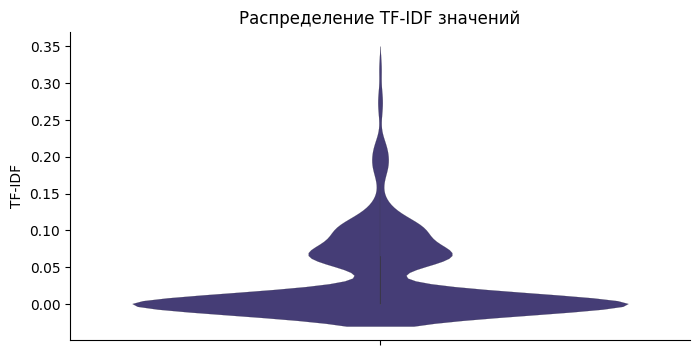

In [24]:
df_long = df_tfidf.melt(var_name="Слово", value_name="TF-IDF")

plt.figure(figsize=(8,4))

sns.violinplot(data=df_long, y="TF-IDF", color='#3E337F', linewidth=0.1)

sns.despine()

plt.title("Распределение TF-IDF значений")
plt.show()

Для большей наглядности посмотрим распределение ненулевых значений TF-IDF

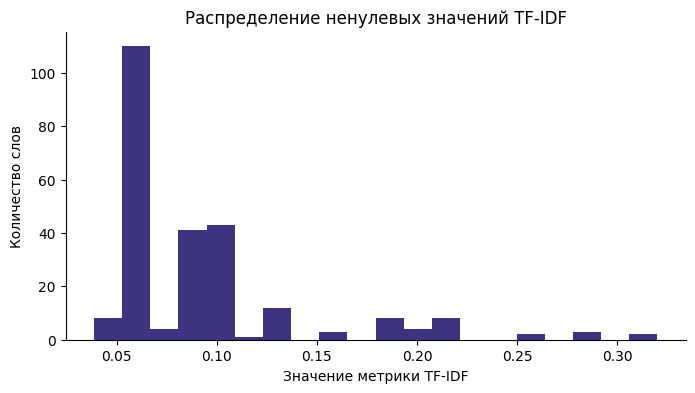

In [25]:
tfidf_values = tfidf_matrix.toarray().flatten()

# Убираем нулевые значения
tfidf_nonzero = tfidf_values[tfidf_values > 0]

plt.figure(figsize=(8,4))

plt.hist(tfidf_nonzero, bins=20, color='#3E337F')

sns.despine()

plt.title("Распределение ненулевых значений TF-IDF")
plt.xlabel("Значение метрики TF-IDF")
plt.ylabel("Количество слов")

plt.show()

### Вывод
Ненулевые значения TF-IDF в основном лежат в диапазоне от 0,5 до 1, что характерно для небольших корпусов документов. Максимальное значение TF-IDF составляет ~0,32 – наиболее характерные слова для конкретной песни. 

Посмотрим самые часто встречающиеся слова в каждой песне

In [26]:
song1_tfidf = df_tfidf.loc["Песня 1"]

top_words_1 = song1_tfidf.sort_values(ascending=False).head(10)
top_words_1

поезд      0.320089
вокзал     0.320089
мирить     0.213393
каждый     0.213393
судьба     0.213393
билет      0.213393
ссорить    0.213393
город      0.162291
пустой     0.162291
любовь     0.126033
Name: Песня 1, dtype: float64

Чем выше график, тем слово важнее для конкретной песни, но реже встречается в других песнях. Слова с наибольшими значениями TF-IDF являются наиболее значимыми для соотвествующего документа, так как они наиболее часто встречаются в данной песне и реже в других.

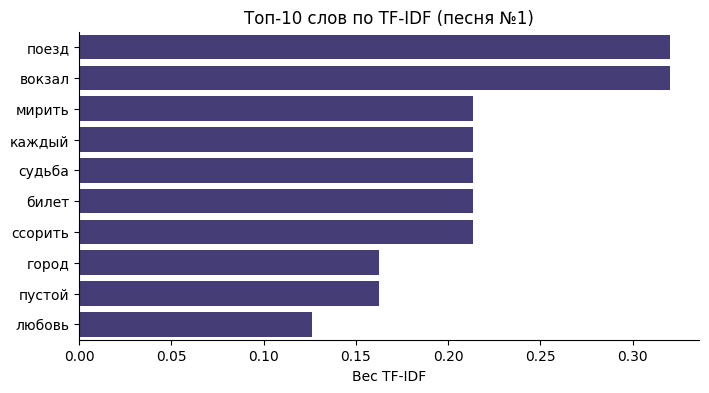

In [27]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=top_words_1.values,
    y=top_words_1.index,
    color='#3E337F'
)
sns.despine()

plt.title("Топ-10 слов по TF-IDF (песня №1)")
plt.xlabel("Вес TF-IDF")
plt.ylabel("")

plt.show()

### Вывод
Для первой песни наиболее характерными словами являются "вокзал", "поезд" и "билет", что отражает основную тематику текста. Судя по распределению значений TF-IDF можно сказать, что песня посвящена путешествиям, дороге и ождиданию. Слова "мирить", "ссорить" и "судьба" указывают на эмоциональную составляющую текста и личные переживания.

Аналогично повторяем для двух остальных песен 

In [28]:
song2_tfidf = df_tfidf.loc["Песня 2"]

top_words_2 = song2_tfidf.sort_values(ascending=False).head(10)
top_words_2

день        0.282851
дом         0.278936
ниоткуда    0.278936
остаться    0.212138
снова       0.212138
забыть      0.212138
значит      0.185958
написать    0.185958
настать     0.185958
новый       0.185958
Name: Песня 2, dtype: float64

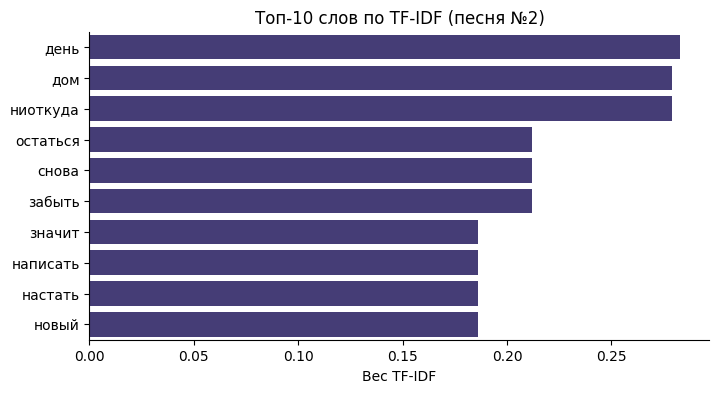

In [29]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=top_words_2.values,
    y=top_words_2.index,
    color='#3E337F'
)
sns.despine()

plt.title("Топ-10 слов по TF-IDF (песня №2)")
plt.xlabel("Вес TF-IDF")
plt.ylabel("")

plt.show()

### Вывод
Во второй песне наибольшие веса получили слова "день", "дом" и "ниоткуда". Они поддерживают атмосферу ожидания и размышлений, присущую данной песне. Также важными оказались слова "забыть", "снова" и "остаться", которые отражают тему воспоминаний и эмоционального состояния лирического героя. 

In [30]:
song3_tfidf = df_tfidf.loc["Песня 3"]

top_words_3 = song3_tfidf.sort_values(ascending=False).head(10)
top_words_3

боль            0.261222
кричать         0.261222
песня           0.195916
район           0.195916
услышать        0.195916
рассвет         0.195916
ответ           0.130611
остановиться    0.130611
обращаться      0.130611
чёрт            0.130611
Name: Песня 3, dtype: float64

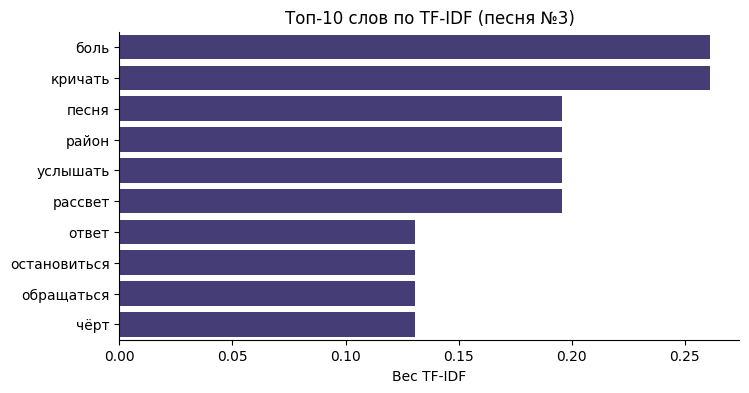

In [31]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=top_words_3.values,
    y=top_words_3.index,
    color='#3E337F'
)
sns.despine()

plt.title("Топ-10 слов по TF-IDF (песня №3)")
plt.xlabel("Вес TF-IDF")
plt.ylabel("")

plt.show()

### Вывод
Для третьей песни ключевыми словами выступают "боль" и "кричать". По такому набору слов можно заключить, что эта песня имеет более выраженную эмоциональную напряженность, чем две предыдущие. Помимо этого, значимыми являются слова "рассвет", "песня" и "услышать", которые отражают тему воспоминаний и переживаний

## Сравнение методов векторизации
Импортируем необходимые библиотеки

In [32]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument

Будем использовать четыре метода векторизации:
- `TF-IDF` - взвешенная модель слов
- `CountVectorizer` - простая частотная модель
- `Word2Vec` - векторы слов
- `Doc2Vec` - векторы документов (песен)

Метод **CountVectorizer** строит матрицу частот слов, где в строках расположены документы, а в столбцах - слова. Значения показывают, сколько раз слово встретилось в тексте.

In [33]:
start = time.time()

count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(processed_songs)

count_time = time.time() - start

print(f'Время вычисления CountVectorizer: {count_time:.6f} секунд')

Время вычисления CountVectorizer: 0.009978 секунд


Метод **Word2Vec** создает вектор для каждого слова, учитывая его контекст, благодаря чему можно определять близость слов по смыслу.

In [34]:
# Разбиваем тексты на слов 
sentences = [song.split() for song in processed_songs]

start = time.time()

# Слово - вектор из 100 чисел
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

end = time.time()
w2v_time = end - start

print(f'Время вычисления Word2Vec: {w2v_time:.6f} секунд')

Время вычисления Word2Vec: 0.043947 секунд


Метод **Doc2Vec** создает вектор для каждого документа, учитывая порядок и контекст слов в нем, благодаря чему можно определять близость целых текстов по смыслу.

In [35]:
# Подготавливаем данные
tagged_data = [
    TaggedDocument(words=song.split(), tags=[f"song_{i}"])
    for i, song in enumerate(processed_songs)
]

start = time.time()

d2v_model = Doc2Vec(
    tagged_data,
    vector_size=100,
    window=5,
    min_count=1,
    epochs=100
)

d2v_time = time.time() - start

print(f'Время выполнения Doc2Vec: {d2v_time:.6f} секунд')

Время выполнения Doc2Vec: 0.764577 секунд


In [36]:
# Записываем вектор из 100 чисел для каждой песни
doc_vectors = [d2v_model.dv[f"song_{i}"] for i in range(len(processed_songs))]
doc_vectors

[array([-1.5016303 , -1.3108244 ,  0.19761474,  0.41581428,  0.8765027 ,
        -1.0505404 ,  0.39514047,  0.26225552, -0.2689558 ,  0.48998925,
        -0.7397634 ,  0.16583075, -1.1495109 , -0.53643954,  0.42042434,
        -0.07068204, -0.43509236, -0.4565642 , -0.37992543, -0.80693233,
        -0.9502309 , -0.30817702,  0.16762504,  0.92107344, -0.60132533,
        -0.00682789, -1.17588   , -0.52822185, -0.7586489 , -0.29327264,
         0.3506899 ,  0.11599958,  0.60711545, -0.70406514, -0.79692817,
         1.1417525 , -0.8732981 , -1.1781936 , -0.8314531 , -1.5303988 ,
         1.1216865 , -0.13089083,  1.1700851 , -0.5074133 ,  0.029188  ,
        -0.16765693, -0.16802931,  0.64854944, -0.04002227, -1.247728  ,
        -0.8075664 , -0.6249283 , -0.5470478 , -1.0458838 , -0.81428725,
         1.8953943 ,  0.5631326 ,  0.8723495 , -0.6593424 ,  0.68563753,
         1.075354  ,  1.7508073 ,  1.2059071 , -0.1745969 , -0.50838554,
         0.24391653,  0.9480427 ,  1.4466643 , -0.3

Сравниваем методы по времени вычисления

In [37]:
times = {
    "CountVectorizer": count_time,
    "TF-IDF": tfidf_time,
    "Word2Vec": w2v_time,
    "Doc2Vec": d2v_time
}

df_times = pd.DataFrame(list(times.items()), columns=["Метод","Время"])

# Сортируем по возрастанию времени выполнения
df_times = df_times.sort_values('Время', ascending=True)
df_times

,Метод,Время
0,CountVectorizer,0.009978
1,TF-IDF,0.014080
2,Word2Vec,0.043947
3,Doc2Vec,0.764577


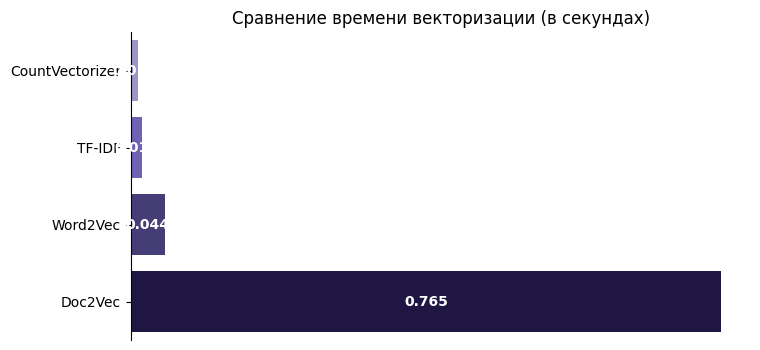

In [38]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=df_times,
    y="Метод",
    x="Время",
    palette=['#9B8AD1', "#6555C3", '#3E337F', '#1A0F4A'],
    orient='h'
)

for i, v in enumerate(df_times["Время"]):
    ax.text(v/2, i, f'{v:.3f}', ha='center', va='center', color='white', fontweight='bold')

ax.axes.get_xaxis().set_visible(False)
sns.despine(left=False, bottom=True)
plt.title("Сравнение времени векторизации (в секундах)")
plt.ylabel("") 
plt.xlabel("")

plt.show()

Метод `CountVectorizer` является самым простым и быстрым, однако он учитывает только частоту слов и не отражает их важность в тексте.

Метод `TF-IDF` учитывает не только частоту слова, но и его распространенность в корпусе, благодаря чему позволяет выделить наиболее значимые слова для каждого документа.

Метод `Word2Vec` представляет слова в виде плотных векторов и учитывает контекст их использования, что обеспечивает более качественное семантическое представление текста. Однако в сравнении с другими методами этот самый долгий по скорости вычисления и сложный в интерпретации.

Метод `Doc2Vec` является расширением Word2Vec на уровень целых документов. В отличие от усреднения векторов слов, Doc2Vec обучает уникальный вектор для документа, позволяя модели захватывать семантику текста целиком. Это делает его эффективным для задач классификации и поиска похожих текстов. Однако Doc2Vec более ресурсоемкий, требует больше данных для качественного обучения и тяжело интерпретируем, так как смысл вектора напрямую не всегда очевиден.

| Метод           | Вычислительная сложность | Качество представления                              | Интерпретируемость |
| :-------------- | :----------------------: | :-------------------------------------------------: | :----------------: |
| CountVectorizer | низкая                   | низкое - учитывает только частоту                   | высокая            |
| TF-IDF          | средняя                  | среднее - учитывает важность слов                   | высокая            |
| Word2Vec        | высокая                  | высокое - учитывает контекст слов                   | низкая             |
| Doc2Vec         | очень высокая            | высокое - учитывает семантику документа целиком     | низкая             |

Сравним схожесть песен между собой. Напрямую сравнивать тексты можно только теми методами, которые дают вектор документа. Метод Word2Vec дает вектор слова, а не документа. Поэтому напрямую сравнить песни нельзя, нужно сначала агрегировать данные путем усреднения слов. 

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

In [40]:
song_names = ["Песня 1", "Песня 2", "Песня 3"]

In [41]:
# CountVectorizer
count_similarity = cosine_similarity(count_matrix)

df_count_sim = pd.DataFrame(
    count_similarity,
    index=song_names,
    columns=song_names
)

df_count_sim

,Песня 1,Песня 2,Песня 3
Песня 1,1.000000,0.136330,0.109386
Песня 2,0.136330,1.000000,0.101044
Песня 3,0.109386,0.101044,1.000000


Метод CountVectorizer показал низкий уровень схожести между песнями (~0.1). Наибольшая близость наблюдается между песнями 1 и 2, что может свидетельствовать о наличии общего словарного запаса. В целом значения остаются низкими, так как метод учитывает только частоту слов и не различает их значимость или контекст.

In [42]:
# TF-IDF
tfidf_similarity = cosine_similarity(tfidf_matrix)

df_tfidf_sim = pd.DataFrame(
    tfidf_similarity,
    index=song_names,
    columns=song_names
)

df_tfidf_sim

,Песня 1,Песня 2,Песня 3
Песня 1,1.000000,0.075866,0.057316
Песня 2,0.075866,1.000000,0.052789
Песня 3,0.057316,0.052789,1.000000


TF-IDF показал ещё более низкие значения схожести (~0.05). Это связано с тем, что метод снижает вес часто встречающихся слов и выделяет только уникальные и значимые термины. В результате песни оказываются ещё менее похожими друг на друга. Это говорит о том, что тексты действительно отличаются по ключевым словам, несмотря на возможную общую тематику (любовь, переживания).

In [43]:
# Усредняем векторы слов
def get_sentence_vector(model, sentence):
    words = sentence.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0)

w2v_vectors = [get_sentence_vector(w2v_model, song) for song in processed_songs]

In [44]:
# Word2Vec 
w2v_similarity = cosine_similarity(w2v_vectors)

df_w2v_sim = pd.DataFrame(
    w2v_similarity,
    index=song_names,
    columns=song_names
)

df_w2v_sim

,Песня 1,Песня 2,Песня 3
Песня 1,1.000000,0.166918,0.313243
Песня 2,0.166918,1.000000,0.192684
Песня 3,0.313243,0.192684,1.000000


Word2Vec продемонстрировал более высокие значения схожести (до 0.31), особенно между песнями 1 и 3. Это означает, что метод смог уловить семантическую близость текстов, даже если в них используются разные слова. Однако из-за усреднения векторов слов теряется информация о структуре текста, что может приводить к завышенной оценке схожести.

In [45]:
# Doc2Vec
doc_similarity = cosine_similarity(doc_vectors)

df_doc2vec_sim = pd.DataFrame(
    doc_similarity,
    index=song_names,
    columns=song_names
)

df_doc2vec_sim

,Песня 1,Песня 2,Песня 3
Песня 1,1.000000,0.998630,0.997732
Песня 2,0.998630,1.000000,0.996658
Песня 3,0.997732,0.996658,1.000000


Doc2Vec показал аномально высокую схожесть между всеми песнями (~0.996). Это означает, что модель практически не различает тексты. Такая ситуация может быть объяснима очень маленьким корпусом (всего 3 документа) и недостатком данных для обучения модели. В результате Doc2Vec не смог адекватно выделить различия между песнями, и его результаты в данном случае нельзя считать информативными.

Собираем результаты в одну таблицу для сравнения

In [46]:
comparison_results = pd.DataFrame({
    "Метод": ["CountVectorizer", "TF-IDF", "Word2Vec", "Doc2Vec"],
    
    "Песня 1 - Песня 2": [
        df_count_sim.iloc[0,1],
        df_tfidf_sim.iloc[0,1],
        df_w2v_sim.iloc[0,1],
        df_doc2vec_sim.iloc[0,1]
    ],
    
    "Песня 1 - Песня 3": [
        df_count_sim.iloc[0,2],
        df_tfidf_sim.iloc[0,2],
        df_w2v_sim.iloc[0,2],
        df_doc2vec_sim.iloc[0,2]
    ],
    
    "Песня 2 - Песня 3": [
        df_count_sim.iloc[1,2],
        df_tfidf_sim.iloc[1,2],
        df_w2v_sim.iloc[1,2],
        df_doc2vec_sim.iloc[1,2]
    ]
})

comparison_results

,Метод,Песня 1 - Песня 2,Песня 1 - Песня 3,Песня 2 - Песня 3
0,CountVectorizer,0.136330,0.109386,0.101044
1,TF-IDF,0.075866,0.057316,0.052789
2,Word2Vec,0.166918,0.313243,0.192684
3,Doc2Vec,0.998630,0.997732,0.996658


Построим тепловую карту схожести песен

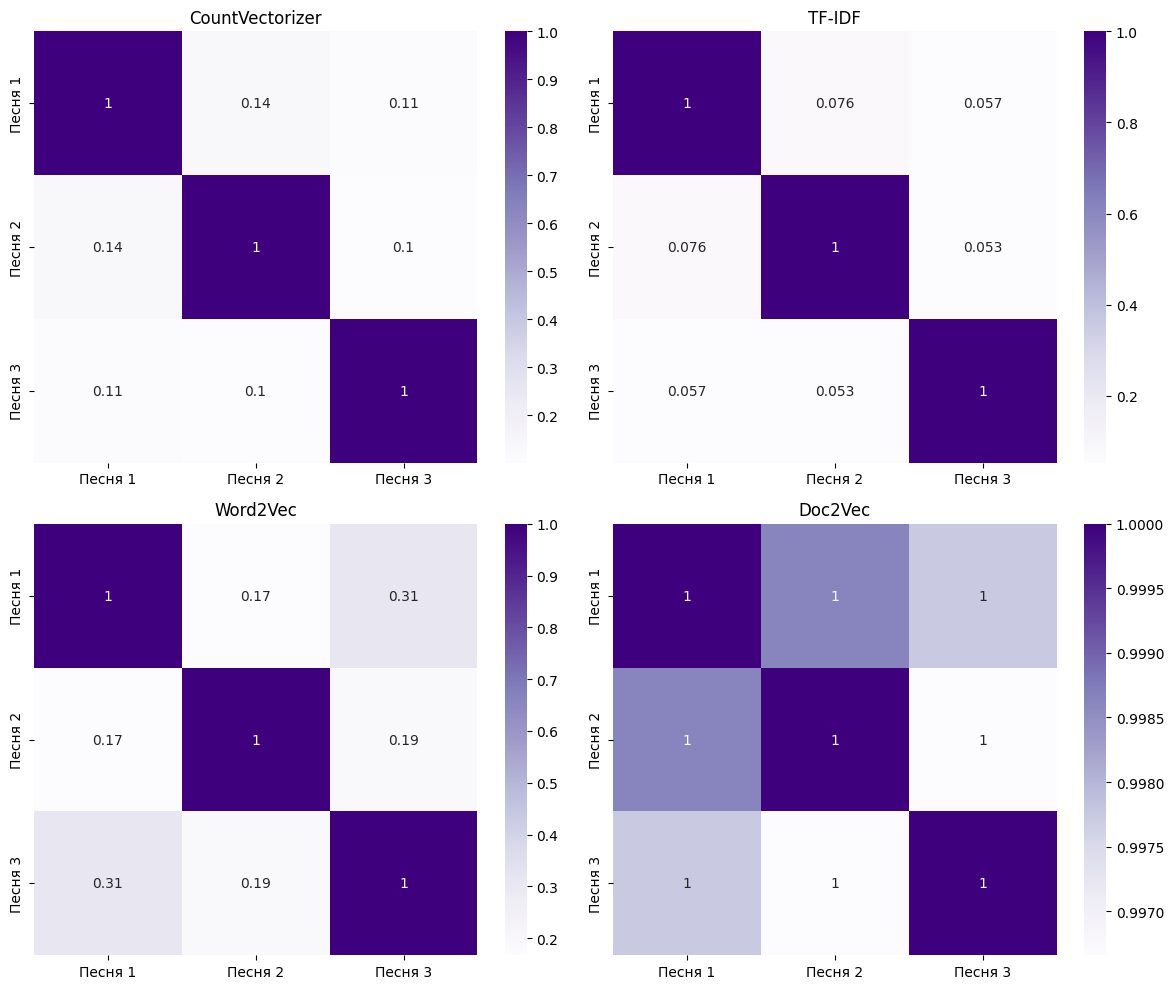

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.heatmap(df_count_sim, annot=True, ax=axes[0,0], cmap="Purples")
axes[0,0].set_title("CountVectorizer")

sns.heatmap(df_tfidf_sim, annot=True, ax=axes[0,1], cmap="Purples")
axes[0,1].set_title("TF-IDF")

sns.heatmap(df_w2v_sim, annot=True, ax=axes[1,0], cmap="Purples")
axes[1,0].set_title("Word2Vec")

sns.heatmap(df_doc2vec_sim, annot=True, ax=axes[1,1], cmap="Purples")
axes[1,1].set_title("Doc2Vec")

plt.tight_layout()
plt.show()

### Вывод
- `CountVectorizer` — показывает базовый уровень схожести, так как учитывает только частоту слов без анализа их значимости. Результаты демонстрируют низкую схожесть текстов.

- `TF-IDF` — дает более строгую оценку схожести, снижая влияние частотных слов и выделяя ключевые термины. В результате тексты выглядят еще менее похожими, что отражает различия в содержании песен.

- `Word2Vec` — учитывает семантическую близость слов, благодаря чему показывает более высокую схожесть текстов. Однако усреднение векторов приводит к потере структуры текста и может завышать степень сходства.

- `Doc2Vec` — формирует вектор документа с учетом контекста, однако на маленьком наборе данных показывает некорректные результаты: все тексты оказываются почти идентичными.

Таким образом, выбор метода векторизации зависит от задачи: для анализа ключевых слов лучше подходят TF-IDF и CountVectorizer, а для выявления семантической близости — Word2Vec. Использование Doc2Vec требует значительно большего корпуса текстов.

Сделаем для всех методов t-SNE визуализацию, чтобы посмотреть, насколько близки песни в векторном пространстве. Чем ближе находятся точки, тем больше похожи песни. 

In [48]:
from sklearn.manifold import TSNE

def plot_tsne_words(matrix, feature_names, title):
    word_vectors = matrix.T.toarray()

    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    reduced = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(10, 8))

    for i, word in enumerate(feature_names):
        plt.scatter(reduced[i, 0], reduced[i, 1])
        
        if i < 30:
            plt.text(reduced[i, 0], reduced[i, 1], word, fontsize=8)

    plt.title(title)
    plt.grid()
    plt.show()

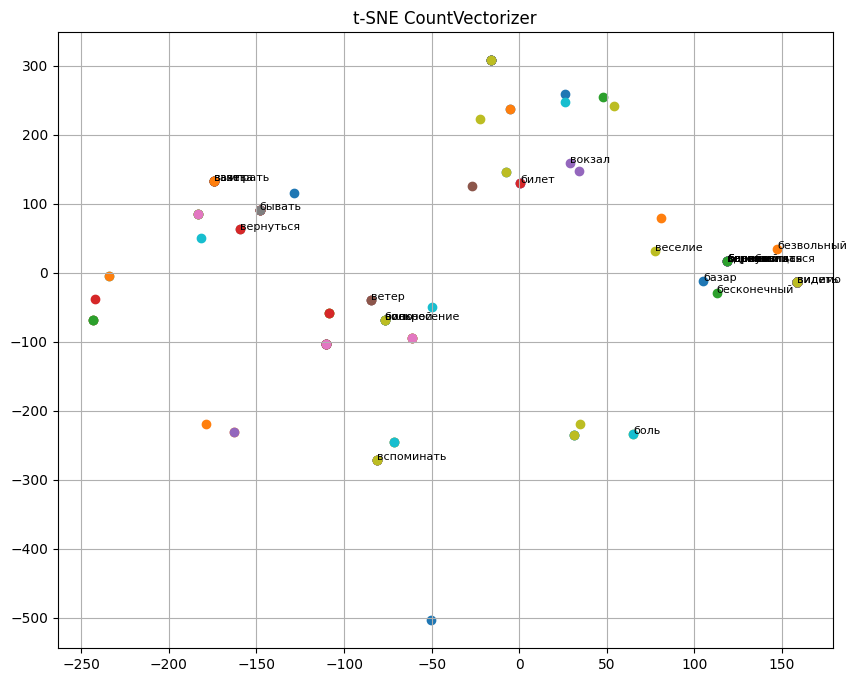

In [49]:
# CountVectorizer
plot_tsne_words(
    count_matrix,
    count_vectorizer.get_feature_names_out(),
    "t-SNE CountVectorizer"
)

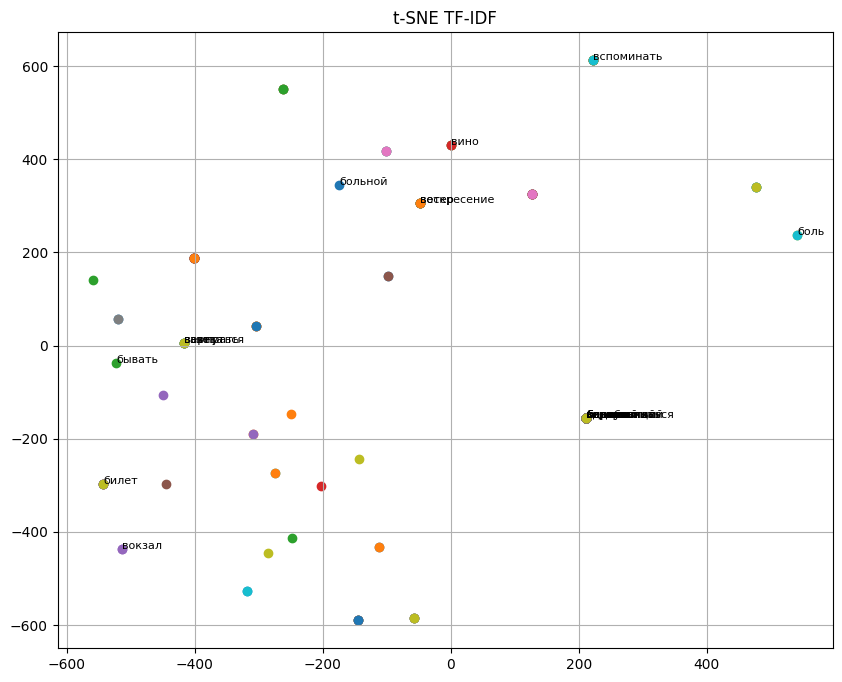

In [50]:
# TF-IDF
plot_tsne_words(
    tfidf_matrix,
    tfidf_vectorizer.get_feature_names_out(),
    "t-SNE TF-IDF"
)

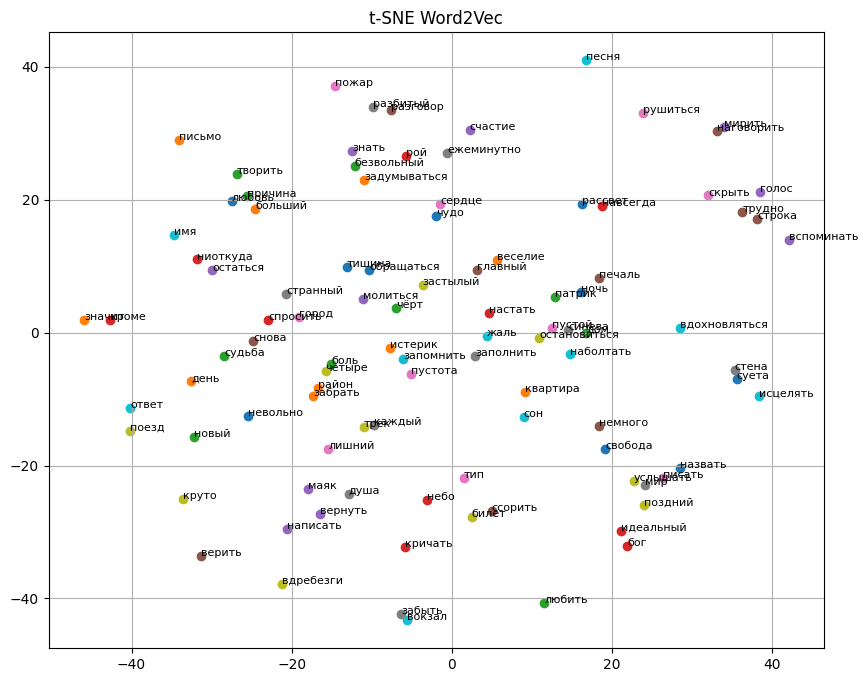

In [51]:
# Word2Vec
def plot_tsne_w2v(model):
    words = model.wv.index_to_key
    vectors = model.wv[words]

    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(10, 8))

    for i, word in enumerate(words[:100]):  # ограничим
        plt.scatter(reduced[i, 0], reduced[i, 1])
        plt.text(reduced[i, 0], reduced[i, 1], word, fontsize=8)

    plt.title("t-SNE Word2Vec")
    plt.grid()
    plt.show()

plot_tsne_w2v(w2v_model)

### Вывод
Методы CountVectorizer и TF-IDF группируют слова по песням, в то время как метод Word2Vec группирует слова по смыслу, поэтому представляет самый ценный результат.

t-SNE методом Doc2Vec по словам сделать нельзя, так как он не хранит слова, а только векторы документов.

Определим ТОП-10 самых частых и редких слов в песнях.

In [52]:
def plot_top_bottom(df, method_name):
    
    top_10 = df.sort_values(by="value", ascending=False).head(10)
    bottom_10 = df[df["value"] > 0].sort_values(by="value").head(10)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # ТОП частых слов
    bars1 = sns.barplot(
        data=top_10,
        x="value",
        y="word",
        color="#3E337F",
        ax=axes[0]
    )
    axes[0].set_title(f"{method_name} - ТОП-10 частых слов")
    axes[0].set_xlabel("")  
    axes[0].set_ylabel("")
    axes[0].set_xticks([]) 
    
    for bar, value in zip(bars1.patches, top_10["value"]):
        text_x = bar.get_width() / 2 
        text_y = bar.get_y() + bar.get_height() / 2 
        axes[0].text(text_x, text_y, f'{value}', 
                    ha='center', va='center', color='white')
    
    # ТОП редких слов
    bars2 = sns.barplot(
        data=bottom_10,
        x="value",
        y="word",
        color="#9B8AD1",
        ax=axes[1]
    )
    axes[1].set_title(f"{method_name} - ТОП-10 редких слов")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    axes[1].set_xticks([]) 
    
    for bar, value in zip(bars2.patches, bottom_10["value"]):
        text_x = bar.get_width() / 2 
        text_y = bar.get_y() + bar.get_height() / 2
        axes[1].text(text_x, text_y, f'{value}', 
                    ha='center', va='center', color='white')

    sns.despine(left=False, bottom=True)
    
    plt.tight_layout()
    plt.savefig('1.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
    plt.show()

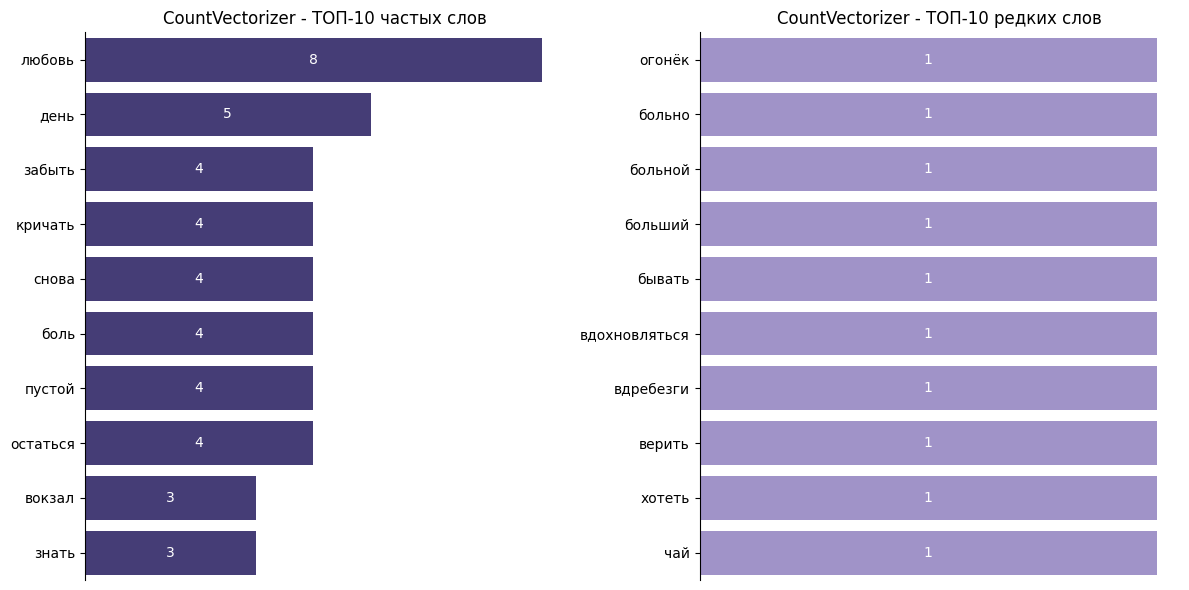

In [53]:
# CountVectorizer
df_count_words = pd.DataFrame({
    "word": count_vectorizer.get_feature_names_out(),
    "value": np.asarray(count_matrix.sum(axis=0)).flatten()
})

plot_top_bottom(df_count_words, "CountVectorizer")

Часто повторяющиеся слова отражают основные темы песен: 
- эмоции - любовь, боль
- состояние - пустой, остаться
- действия - забыть, кричать 

Алгоритм хорошо показывает частотные паттерны, но не различает важность слов

Редкие слова не особо значимы, так как они встречаются по 1 разу в тексте и не влияют на общую картину. 

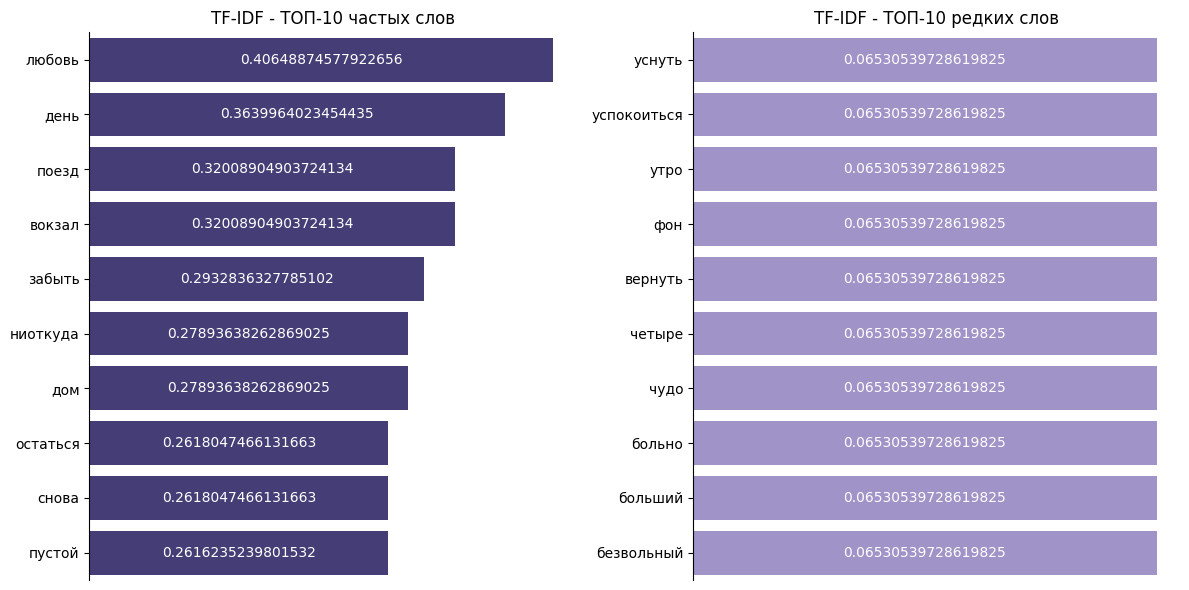

In [54]:
# TF-IDF
df_tfidf_words = pd.DataFrame({
    "word": tfidf_vectorizer.get_feature_names_out(),
    "value": np.asarray(tfidf_matrix.sum(axis=0)).flatten()
})

plot_top_bottom(df_tfidf_words, "TF-IDF")

Метод выделяет редкие, но важные слова. Например, слова вокзал и поезд уникальны для песни №1, поэтому имеют высокий вес. С этой точки зрения, TF-IDF лучше выявляет уникальные темы каждой песни. Редкие слова все имеют вес 0.7, так как встречаются только 1 раз. Эти слова либо редкие, либо незначимые в контексте. 

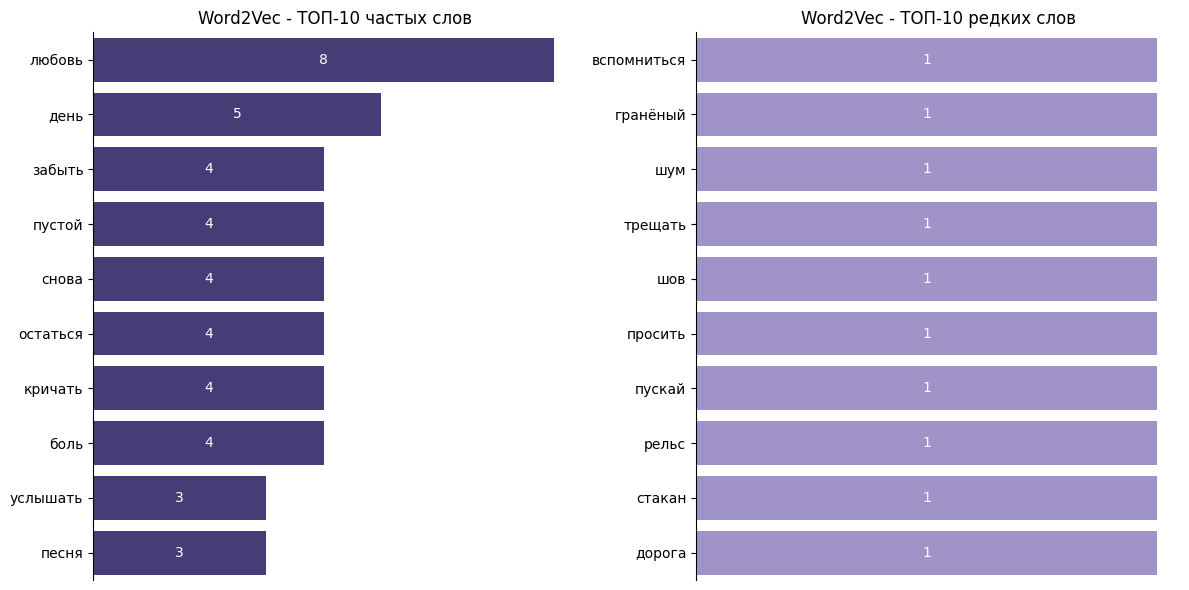

In [55]:
# Word2Vec
word_counts_w2v = [
    (word, w2v_model.wv.get_vecattr(word, "count"))
    for word in w2v_model.wv.index_to_key
]

df_w2v = pd.DataFrame(word_counts_w2v, columns=["word", "value"])

plot_top_bottom(df_w2v, "Word2Vec")

Поскольку здесь анализируются частоты, то результаты совпадают с вычислениями для метода CountVectorizer.

Построим тепловую карту для трех песен

In [56]:
# CountVectorizer
df_count = pd.DataFrame(
    count_matrix.toarray(),
    index=["Песня 1","Песня 2","Песня 3"],
    columns=count_vectorizer.get_feature_names_out()
)

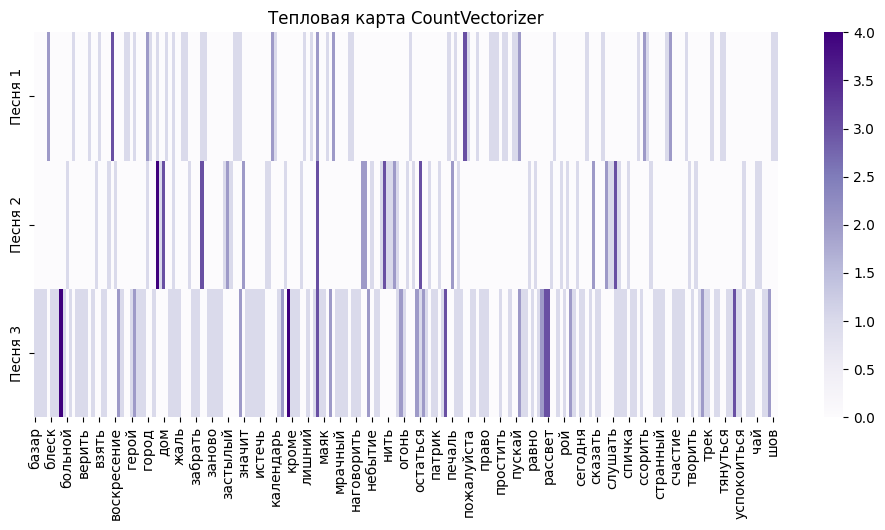

In [57]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df_count,
    cmap="Purples"
)

plt.title("Тепловая карта CountVectorizer")
plt.show()

Так как метод CountVectorizer дает много слов, то для большей читаемости ограничим набор данных ТОП-20 словами

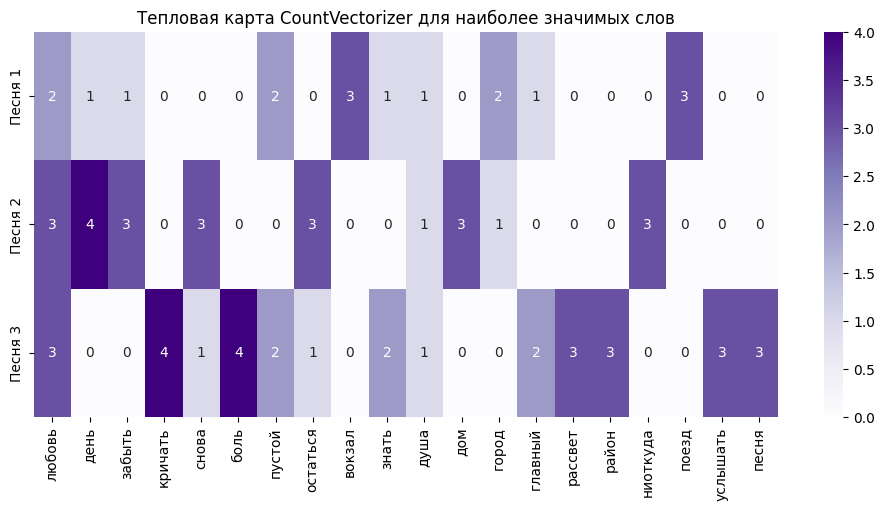

In [58]:
top_words = df_count.sum().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12,5))

sns.heatmap(
    df_count[top_words],
    cmap="Purples",
    annot=True
)

plt.title("Тепловая карта CountVectorizer для наиболее значимых слов")
plt.show()

Некоторые слова встречаются в нескольких песнях (любовь, душа, город). Большое количество 0 в матрице свидетельствует о том, что многие слова уникальны для одной песни и не повторяются в двух других.

In [59]:
# TF-IDF
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=["Песня 1","Песня 2","Песня 3"],
    columns=tfidf_vectorizer.get_feature_names_out()
)

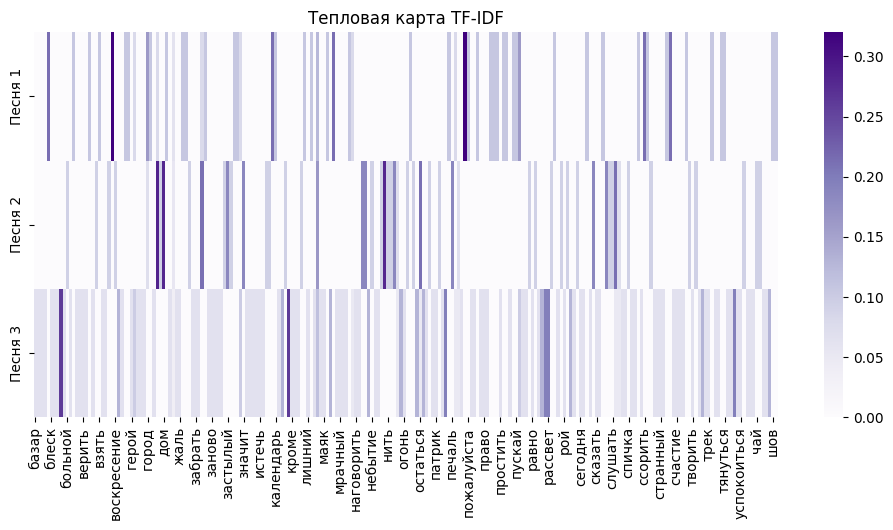

In [60]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df_tfidf,
    cmap="Purples"
)

plt.title("Тепловая карта TF-IDF")
plt.show()

Для лучшей читаемости аналогично ограничим матрицу по 20 самым значимым словам

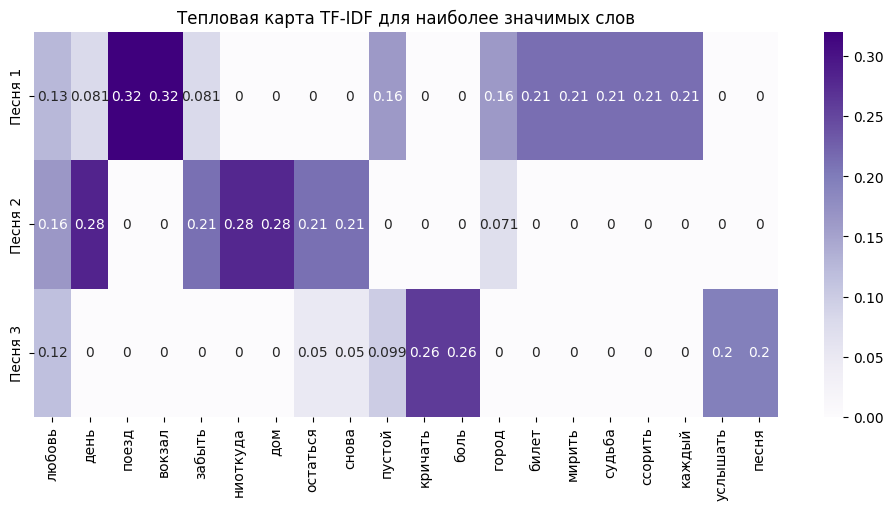

In [61]:
top_words = df_tfidf.sum().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12,5))

sns.heatmap(
    df_tfidf[top_words],
    cmap="Purples",
    annot=True
)

plt.title("Тепловая карта TF-IDF для наиболее значимых слов")
plt.show()


Максимальный вес по TF-IDF ~0.32. Многие слова имеют вес от 0.06 до 0.1. Таким образом, большинство слов имеют слабую важность, и есть несколько ключевых слов. 

In [62]:
# Word2Vec
df_w2v_vectors = pd.DataFrame(
    w2v_vectors,
    index=["Песня 1","Песня 2","Песня 3"]
)

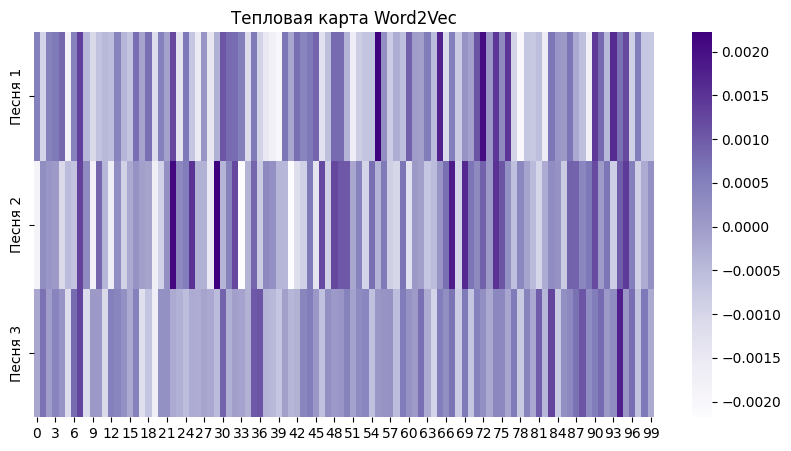

In [63]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df_w2v_vectors,
    cmap="Purples"
)

plt.title("Тепловая карта Word2Vec")
plt.show()

Все значения маленькие (~0.001), есть отрицательные значения. По оси х на графике отображены координаты в прстранстве признаков, которые не могут быть интерпретированы как важность конкретных слов из песни. 

In [64]:
# Doc2Vec
df_doc2vec = pd.DataFrame(
    doc_vectors,
    index=["Песня 1","Песня 2","Песня 3"]
)

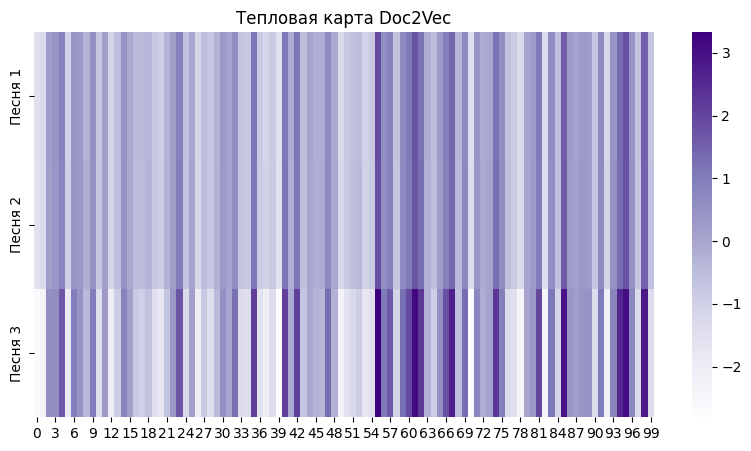

In [65]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df_doc2vec,
    cmap="Purples"
)

plt.title("Тепловая карта Doc2Vec")
plt.show()

Здесь значения больше и достигают ~3. Матрицу Doc2Vec нельзя интерпретировать по словам, а можно только сравнивать тексты и считать их схожесть. 

### Вывод
Методы `CountVectorizer` и `Word2Vec` в части анализа частот показали совпадающие результаты, так как в обоих случаях использовалась частота встречаемости слов. Эти методы позволяют определить наиболее употребляемые слова, однако не учитывают их значимость в контексте документа.

Метод `TF-IDF` продемонстрировал более качественный результат, выделяя не только частотные, но и наиболее информативные слова. Он позволяет определить уникальные характеристики каждой песни и снижает влияние часто встречающихся, но малоинформативных слов.

Методы `Word2Vec` и `Doc2Vec` формируют векторные представления в скрытом пространстве признаков. В отличие от частотных подходов, они не предназначены для анализа значимости отдельных слов. Word2Vec отражает семантическую близость слов, тогда как Doc2Vec формирует обобщенное представление всего текста. Это делает их более подходящими для задач сравнения текстов, но менее интерпретируемыми.

Таким образом, для анализа структуры текста и выделения ключевых слов наиболее эффективным оказался TF-IDF, а для оценки семантической близости текстов целесообразно использовать Word2Vec и Doc2Vec.


Построим облако слов для трех методов: CountVectorizer, TF-IDF и Word2Vec

In [66]:
from wordcloud import WordCloud

def plot_wordcloud(word_dict, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate_from_frequencies(word_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

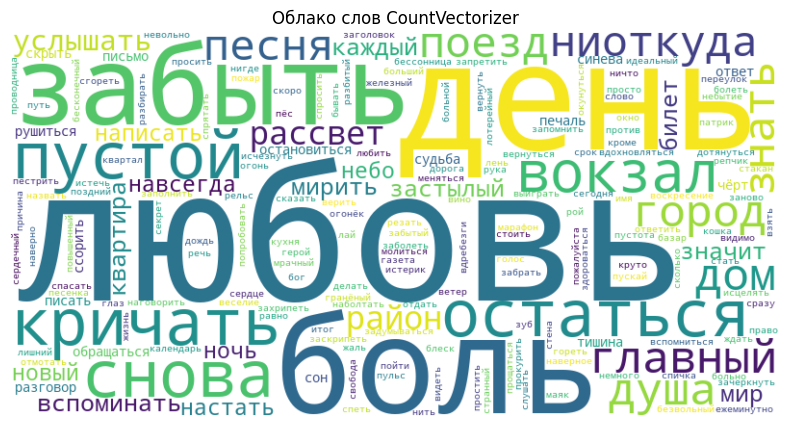

In [67]:
# CountVectorizer
word_counts = np.asarray(count_matrix.sum(axis=0)).flatten()
word_dict = dict(zip(count_vectorizer.get_feature_names_out(), word_counts))

plot_wordcloud(word_dict, "Облако слов CountVectorizer")

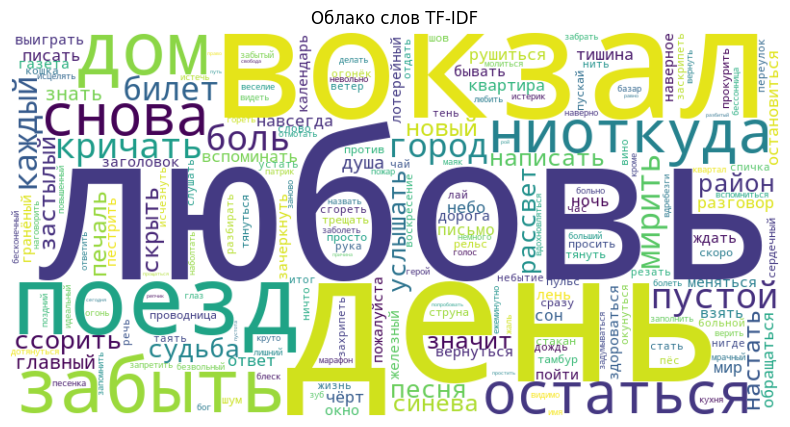

In [68]:
# Tf-IDF
tfidf_sums = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
word_dict_tfidf = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_sums))

plot_wordcloud(word_dict_tfidf, "Облако слов TF-IDF")

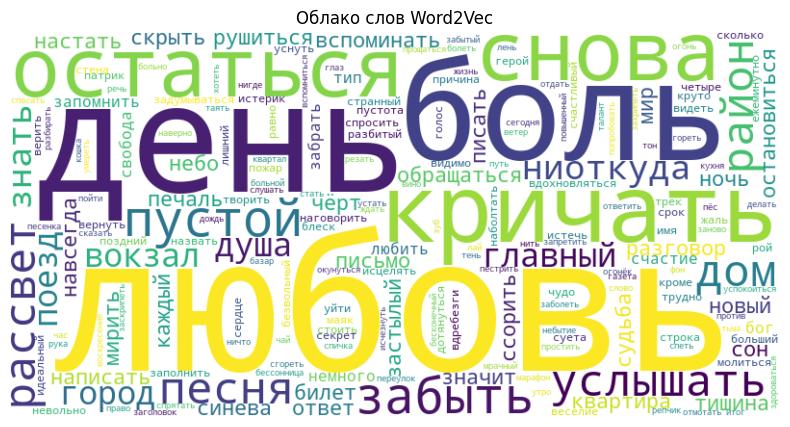

In [69]:
# Word2Vec
word_counts_w2v = {
    word: w2v_model.wv.get_vecattr(word, "count")
    for word in w2v_model.wv.index_to_key
}

plot_wordcloud(word_counts_w2v, "Облако слов Word2Vec")

### Вывод
Набор слов отличается в разных методах. Самые частые слова совпадают - это "любовь", "день", "боль", "забыть" и "снова". Они встречаются  в нескольких песнях чаще всего, поэтому в облаке слова выделены крупным шрифтом.

В облаке слов по методу TF-IDF нет слова "остаться", в отличие от двух других методов. Метод TF-IDF, напротив, выделяет крупным слова "вокзал" и "поезд" - специфичные слова, которые встречаются только в песни №1. Это объяснимо тем, что TF-IDF отдает предпочтение редким словам, встречающимся только в одном тексте, в то время как общие  между разными песнями слова получают низкий вес. 

Дополнительно построим визуализации для каждой песни по-отдельности

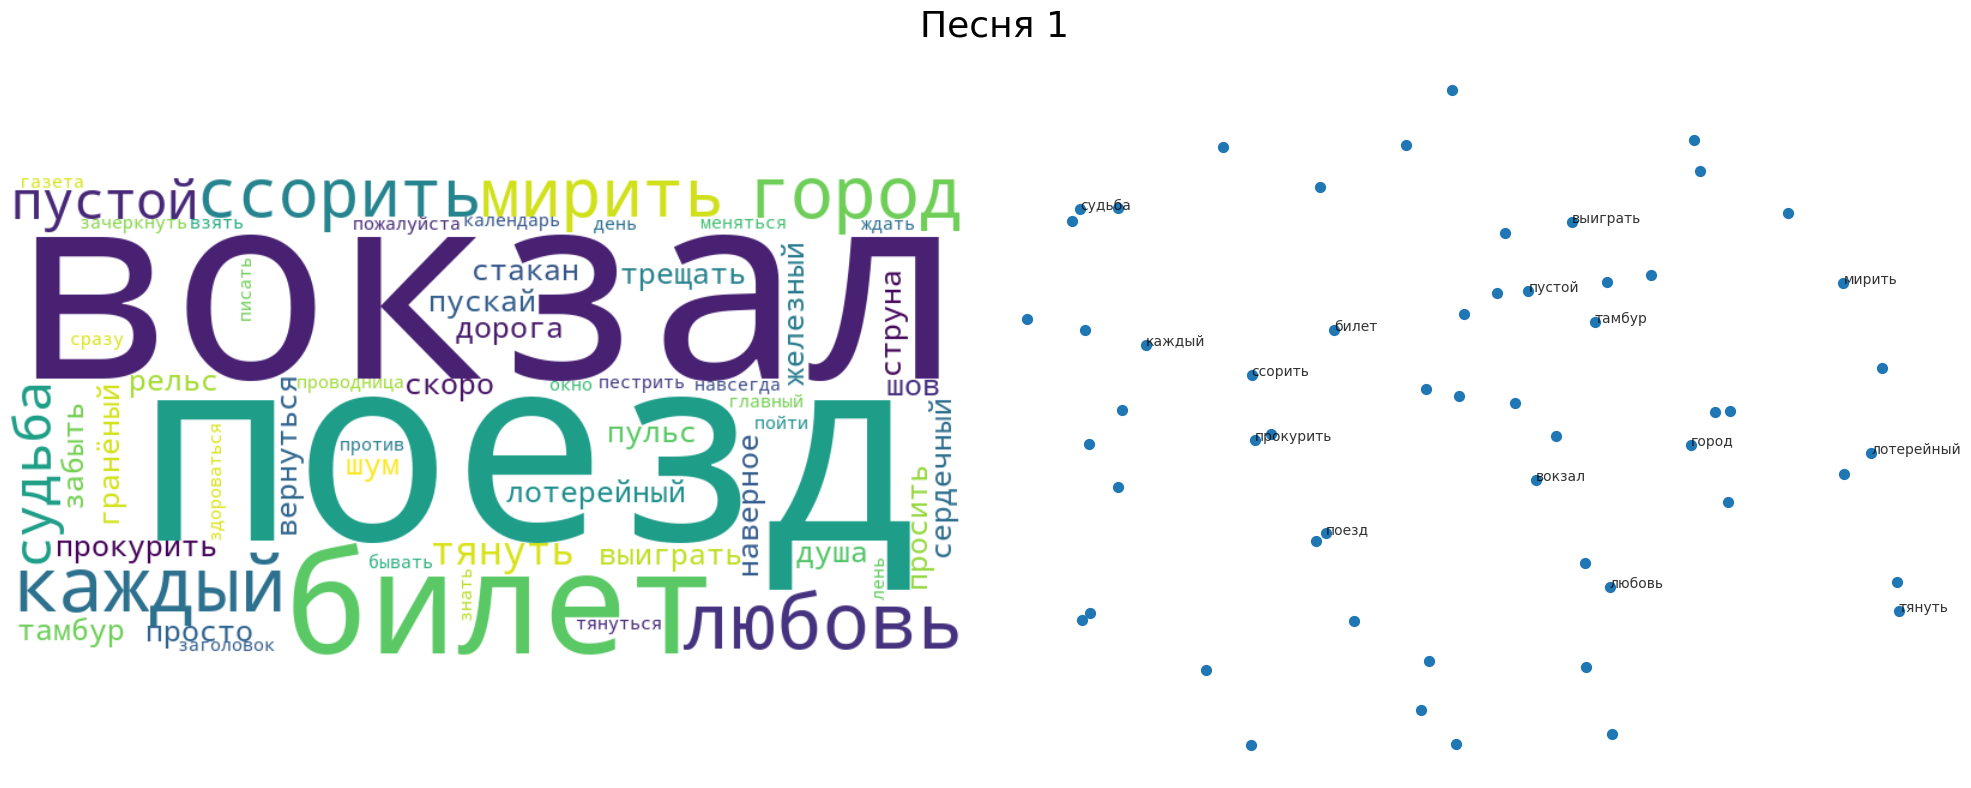

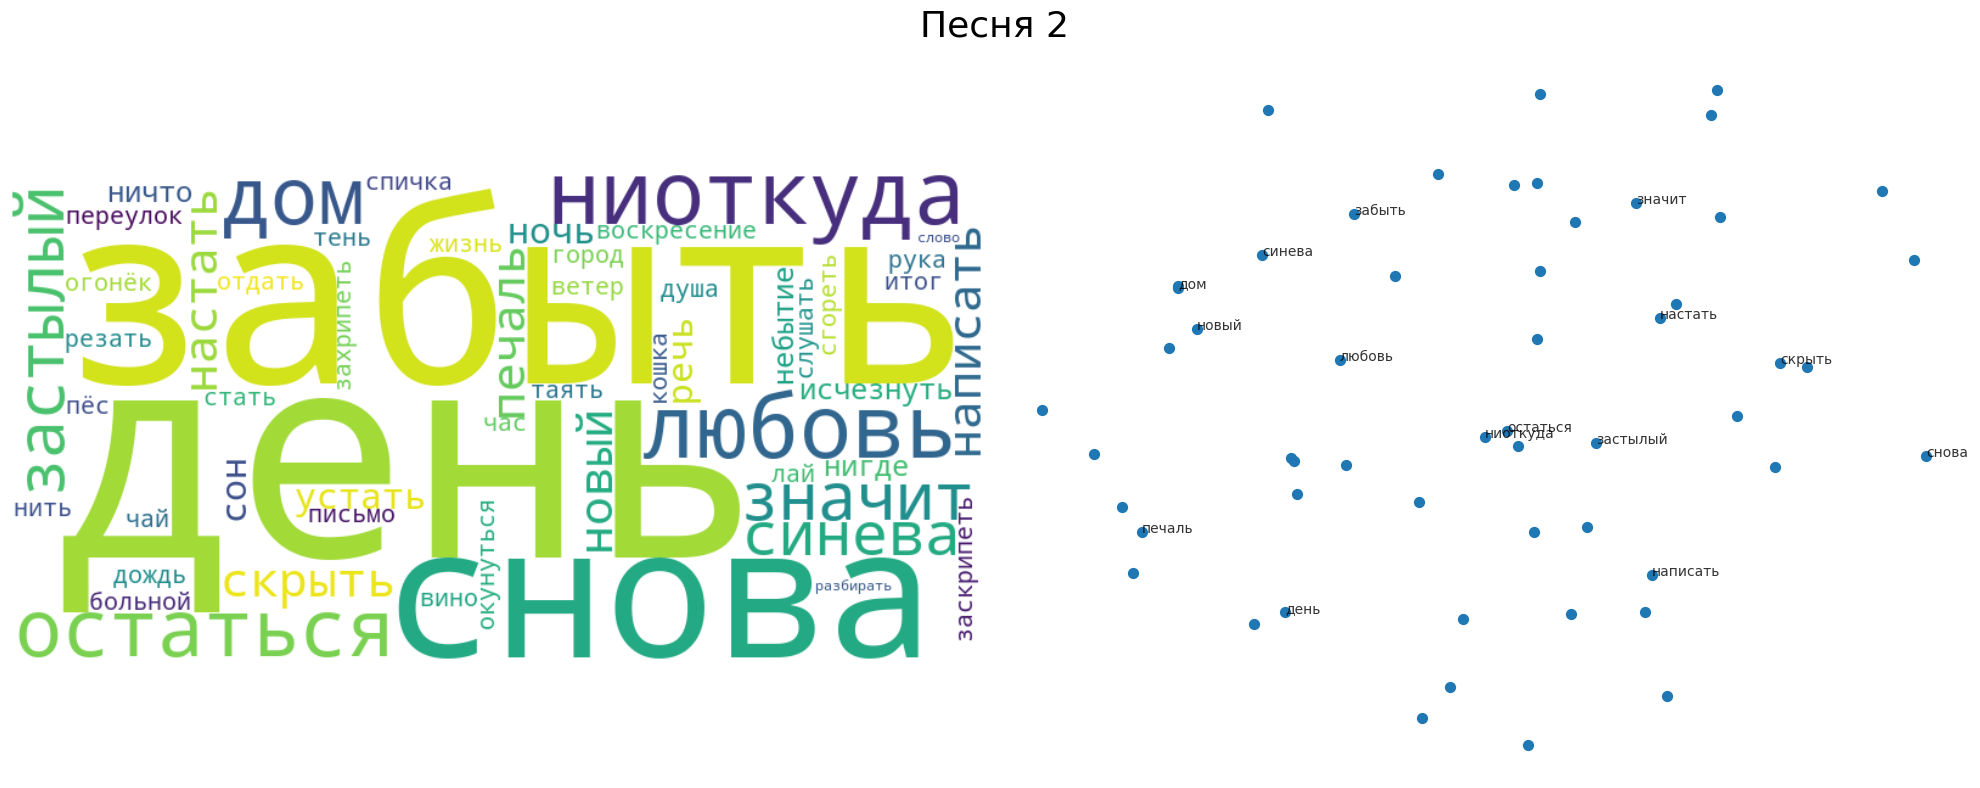

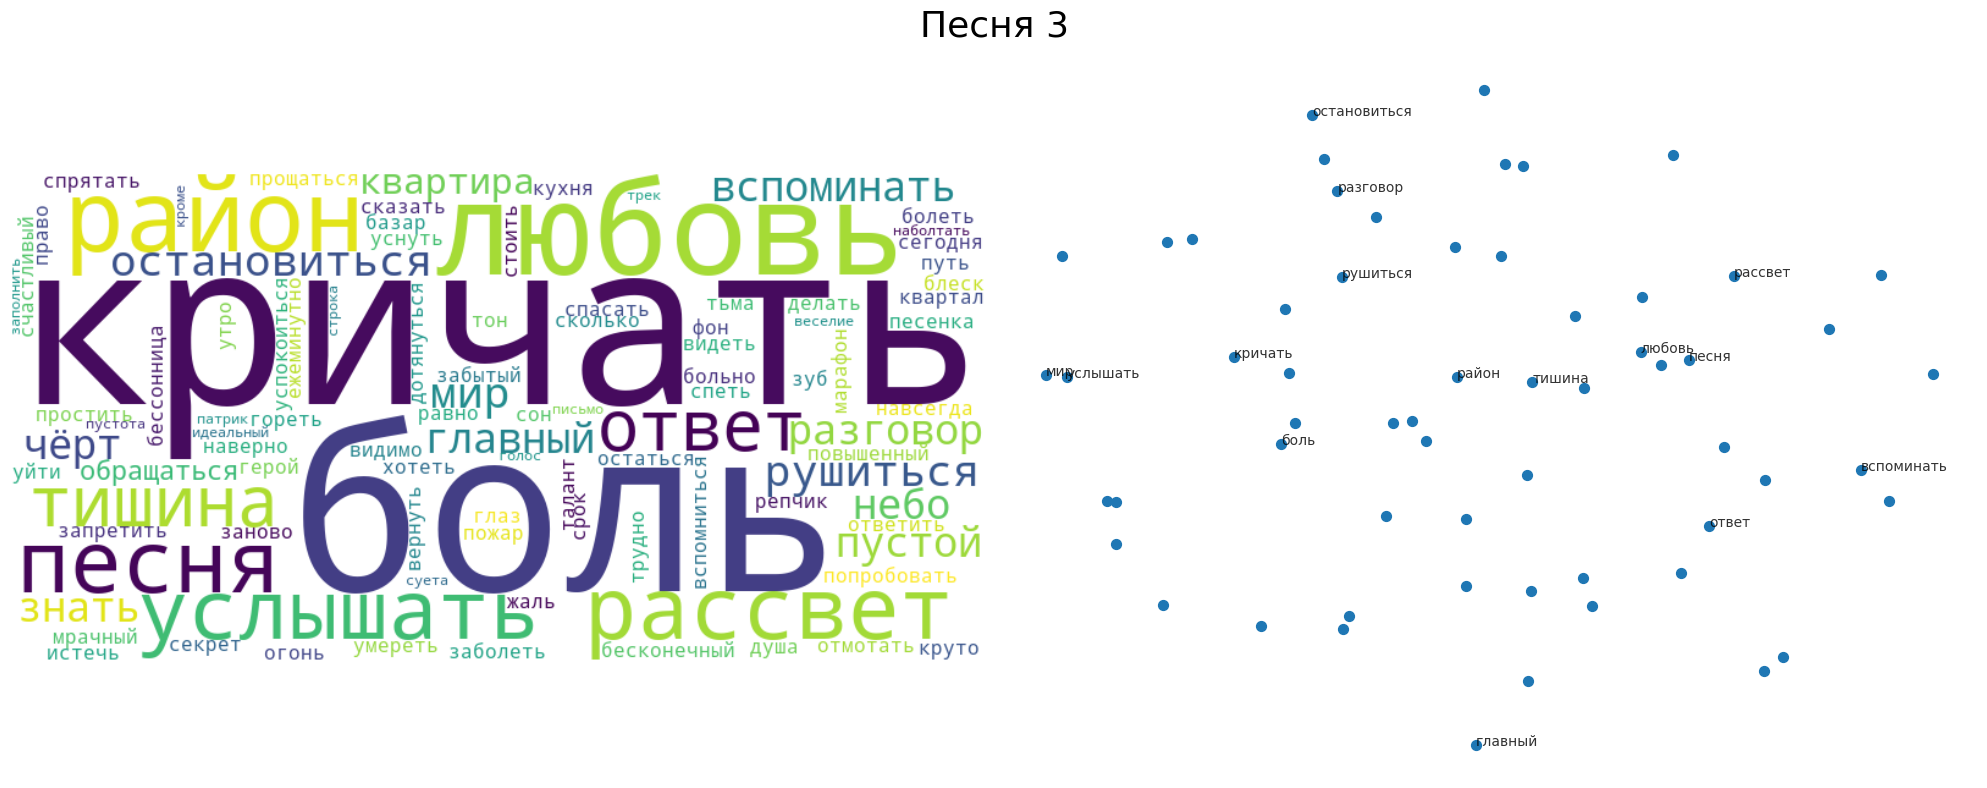

In [78]:
for i, song_text in enumerate(processed_songs):
    song_name = song_names[i] if i < len(song_names) else f"Песня {i+1}"
    tokens = song_text.split()
    token_counts = Counter(tokens)
    token_counts_w2v = {w: c for w, c in token_counts.items() if w in w2v_model.wv}
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(song_name, fontsize=24)
    
    # Облако слов
    if token_counts_w2v:
        wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate_from_frequencies(token_counts_w2v)
        axes[0].imshow(wordcloud, interpolation='bilinear')
        axes[0].axis('off')
    
    # t-SNE
    words = [w for w, _ in Counter(tokens).most_common(60) if w in w2v_model.wv]
    if len(words) >= 2:
        vectors = np.array([w2v_model.wv[word] for word in words])
        perplexity = max(2, min(30, len(words) - 1))
        coords = TSNE(n_components=2, random_state=42, perplexity=perplexity, init="pca").fit_transform(vectors)
        axes[1].scatter(coords[:, 0], coords[:, 1], s=50)
        for idx, w in enumerate(words[:15]):
            axes[1].annotate(w, (coords[idx, 0], coords[idx, 1]), alpha=0.8)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## Часть 2. Классификация тональности отзывов о фильмах
Импортируем необходимые библиотеки. Поскольку PyTorch поддерживает только версии Python до 3.12, важно использовать более старую версию питона. Я использовала Python 3.9.13. 

In [1]:
import pandas as pd
import numpy as np
import torch
import re
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import BertTokenizer, BertTokenizerFast, AutoModel
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

[nltk_data] Downloading package stopwords to /Users/user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/user/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Устанавливаем модули для предобработки текста

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stopwords_set = set(stopwords.words('english'))

Загружаем датасет

In [40]:
df = pd.read_csv('/Users/user/Library/Mobile Documents/com~apple~CloudDocs/HSE/2 курс/Методы и средства обработки больших данных/ДЗ №2/IMDB Dataset.csv')

Обучение модели происходит слишком долго, поэтому чтобы ускорить выполнение кода, я взяла подвыборку из датасета с сохранением точности модели выше 90%. 

In [41]:
df = df.sample(frac=0.3, random_state=42).reset_index(drop=True)

In [42]:
df.head(3)

,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative


Предварительно обрабатываем датасет:
- убираем html-тэги
- убираем пунктуацию
- убираем лишние пробелы

In [43]:
def text_preprocessing(text):
    text = text.lower()
    text = re.sub(r"<br />|--|'ve|'s|'m|'d|'re|'ll", " ", text)
    text = re.sub(r'[!?.)"#(;*,\]\[:]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [44]:
start_time = time.time()

df['processed_review'] = df.review.apply(text_preprocessing)

end_time = time.time()
print(f"Время выполнения: {end_time - start_time:.2f} секунд")

print("\nПример предобработанного текста:")
print(df['processed_review'][0])

Время выполнения: 1.62 секунд
Пример предобработанного текста:
i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslam ever if the wwf didn't have lex luger in the main event against yokozuna now for it time it was ok to have a huge fat man vs a strong man but i glad times have changed it was a terrible main event just like every match luger is in is terrible other matches on the card were razor ramon vs ted dibiase steiner brothers vs heavenly bodies shawn michaels vs curt hening this was the event where shawn named his big monster of a body guard diesel irs vs 1-2-3 kid bret hart first takes on doink then takes on jerry lawler and stuff with the harts and lawler was always very interesting then ludvig borga destroyed marty jannetty undertaker took on giant gonzalez in another terrible match the smoking gunns and tatanka took on bam bam bigelow and t

Разделяем датасет на обучающую и тестовую выборки

In [45]:
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["processed_review"].values,
    df["sentiment"].values,
    test_size=0.2,
    random_state=42
)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print(f'Размер обучающей выборки: {len(train_texts)}')
print(f'Размер тестовой выборки: {len(test_texts)}')

12000 3000


Делаем токенизацию

In [46]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

all_texts = list(train_texts) + list(test_texts)

max_len = 64 

encodings = tokenizer(
    all_texts,
    truncation=True,
    padding='max_length', 
    max_length=max_len,
    return_tensors='pt'
)

train_encodings = {
    "input_ids": encodings["input_ids"][:len(train_texts)],
    "attention_mask": encodings["attention_mask"][:len(train_texts)]
}

test_encodings = {
    "input_ids": encodings["input_ids"][len(train_texts):],
    "attention_mask": encodings["attention_mask"][len(train_texts):]
}

Создаем модель BERT

In [47]:
device = torch.device("cpu")

bert_model = AutoModel.from_pretrained("bert-base-uncased")

class BertBinaryClassifier(nn.Module):
    def __init__(self, bert):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        logits = self.classifier(pooled_output)
        return logits

model = BertBinaryClassifier(bert_model).to(device)

Dataset + DataLoader

In [48]:
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx]
        }, self.labels[idx]

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(train_encodings, train_labels)
test_dataset = CustomDataset(test_encodings, test_labels)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

Обучаем модель BERT

In [49]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

epochs = 2

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # Обучение модели
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(train_dataloader, desc=f"Training {epoch+1}"):

        inputs, labels = batch

        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask=attention_mask).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.numel()

    train_loss = total_loss / len(train_dataloader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Train Loss = {train_loss:.4f} | Train Acc = {train_acc:.4f}")

    # Валидация модели
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"Validation {epoch+1}"):

            inputs, labels = batch

            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask=attention_mask).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.numel()

    val_loss /= len(test_dataloader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Val Loss = {val_loss:.4f} | Val Acc = {val_acc:.4f}")


Epoch 1/2


Training 1: 100%|█████████████████████████████████████████████████████| 750/750 [2:15:31<00:00, 10.84s/it]


Train Loss = 0.4435 | Train Acc = 0.7897


Validation 1: 100%|█████████████████████████████████████████████████████| 188/188 [05:48<00:00,  1.86s/it]


Val Loss = 0.3463 | Val Acc = 0.8423

Epoch 2/2


Training 2: 100%|█████████████████████████████████████████████████████| 750/750 [1:25:21<00:00,  6.83s/it]


Train Loss = 0.2677 | Train Acc = 0.8887


Validation 2: 100%|█████████████████████████████████████████████████████| 188/188 [06:03<00:00,  1.93s/it]

Val Loss = 0.3755 | Val Acc = 0.8327


Считаем метрики оценки качества модели

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Calculating metrics"):

        inputs, labels = batch

        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask).squeeze()
        preds = (torch.sigmoid(outputs) >= 0.5).int().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Calculating metrics: 100%|██████████████████████████████████████████████| 188/188 [05:47<00:00,  1.85s/it]


Precision: 0.8695
Recall: 0.7883
F1-score: 0.8269


Строим графики для оценки качества модели на разных эпохах

In [ ]:
plt.figure(figsize=(10, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', color='#3E337F')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss', color='#9B8AD1')
plt.title('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Train Acc', color='#3E337F')
plt.plot(range(1, epochs+1), val_accuracies, label='Val Acc', color='#9B8AD1')
plt.title('Accuracy')
plt.legend()

plt.show()

In [54]:
results_df = pd.DataFrame({
    'Epoch': range(1, epochs+1),
    'Train Loss': train_losses,
    'Val Loss': val_losses,
    'Train Accuracy': train_accuracies,
    'Val Accuracy': val_accuracies
})

print(results_df.to_string(index=False))

 Epoch  Train Loss  Val Loss  Train Accuracy  Val Accuracy
     1    0.443493  0.346255        0.789667      0.842333
     2    0.267711  0.375489        0.888667      0.832667


In [57]:
print(f"Лучшая точность на валидации: {max(val_accuracies):.4f} (эпоха {val_accuracies.index(max(val_accuracies))+1})")
print(f"Лучшая потеря на валидации: {min(val_losses):.4f} (эпоха {val_losses.index(min(val_losses))+1})")

print(f"\nФинальная точность на валидации: {val_accuracies[-1]:.4f}")
print(f"Финальная потеря на валидации: {val_losses[-1]:.4f}")


Лучшая точность на валидации: 0.8423 (эпоха 1)
Лучшая потеря на валидации: 0.3463 (эпоха 1)

Финальная точность на валидации: 0.8327
Финальная потеря на валидации: 0.3755


### Вывод
Значение метрики `precision` - высокое (0,87), `F1-score` - сбалансированное (0,82), а вот `recall` - проседает (0,79). Модель хорошо угадывает положительные отзывы, но пропускает часть положительных отзывов, о чем свидетельствует заниженная метрика recall. 

По эпохам можно увидеть, что началось переобучение: модель стала лучше на train, но хуже на val. Таким образом, лучшая модель на эпохе 1, а не на эпохе 2. Поэтому оставим 1 эпоху и обучим модель еще раз. 

Я попробовала сделать это на устройстве с GPU, чтобы ускорить время обучения в сравнении с CPU (модель обучилась за ~1 час). 
Значения метрик получились такими:
- `precision` - 0.7504
- `recall` - 0.9408
- `F1-score` - 0.8349

Как можно заметить, метрика recall существенно выросла за счет сокращения точности модели. Значение F1 осталось на том же уровне. Высокая полнота модели означает, что она успешно находит большинство положительных отзывов. Однако низкая точность указывает на наличие ложноположительных предсказаний: модель иногда ошибочно относит негативные отзывы к положительным. 

В целом, модель склонна "перестраховываться", то есть она лучше находит все положительные отзывы, даже ценой ошибок. Такая модель подойдет для задач, где важно не пропустить положительный класс, но для более строгой классификации требуется улучшение precision.

Чтобы повысить точность модели, скорректируем параметры:
- `размер повыборки` - 50% вместо 30%
- `max_len` - 128 вместо 64
- `поколение` - 1 вместо 2

In [69]:
df = pd.read_csv('/Users/user/Library/Mobile Documents/com~apple~CloudDocs/HSE/2 курс/Методы и средства обработки больших данных/ДЗ №2/IMDB Dataset.csv')


In [70]:
df = df.sample(frac=0.5, random_state=42).reset_index(drop=True)

In [71]:
df.head(3)

,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative


Предварительно обрабатываем датасет:
- убираем html-тэги
- убираем пунктуацию
- убираем лишние пробелы

In [72]:
def text_preprocessing(text):
    text = text.lower()
    text = re.sub(r"<br />|--|'ve|'s|'m|'d|'re|'ll", " ", text)
    text = re.sub(r'[!?.)"#(;*,\]\[:]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [73]:
start_time = time.time()

df['processed_review'] = df.review.apply(text_preprocessing)

end_time = time.time()
print(f"Время выполнения: {end_time - start_time:.2f} секунд")

print("\nПример предобработанного текста:")
print(df['processed_review'][0])

Время выполнения: 2.96 секунд

Пример предобработанного текста:
i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslam ever if the wwf didn't have lex luger in the main event against yokozuna now for it time it was ok to have a huge fat man vs a strong man but i glad times have changed it was a terrible main event just like every match luger is in is terrible other matches on the card were razor ramon vs ted dibiase steiner brothers vs heavenly bodies shawn michaels vs curt hening this was the event where shawn named his big monster of a body guard diesel irs vs 1-2-3 kid bret hart first takes on doink then takes on jerry lawler and stuff with the harts and lawler was always very interesting then ludvig borga destroyed marty jannetty undertaker took on giant gonzalez in another terrible match the smoking gunns and tatanka took on bam bam bigelow and 

Разделяем датасет на обучающую и тестовую выборки

In [74]:
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["processed_review"].values,
    df["sentiment"].values,
    test_size=0.2,
    random_state=42
)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print(f'Размер обучающей выборки: {len(train_texts)}')
print(f'Размер тестовой выборки: {len(test_texts)}')

Размер обучающей выборки: 20000
Размер тестовой выборки: 5000


Делаем токенизацию

In [75]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

all_texts = list(train_texts) + list(test_texts)

max_len = 128

encodings = tokenizer(
    all_texts,
    truncation=True,
    padding='max_length', 
    max_length=max_len,
    return_tensors='pt'
)

train_encodings = {
    "input_ids": encodings["input_ids"][:len(train_texts)],
    "attention_mask": encodings["attention_mask"][:len(train_texts)]
}

test_encodings = {
    "input_ids": encodings["input_ids"][len(train_texts):],
    "attention_mask": encodings["attention_mask"][len(train_texts):]
}

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f19b7357-7145-4118-a4b6-781f6ed45cde)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


Создаем модель BERT

In [76]:
device = torch.device("cpu")

bert_model = AutoModel.from_pretrained("bert-base-uncased")

class BertBinaryClassifier(nn.Module):
    def __init__(self, bert):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        logits = self.classifier(pooled_output)
        return logits

model = BertBinaryClassifier(bert_model).to(device)

Dataset + DataLoader

In [77]:
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx]
        }, self.labels[idx]

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(train_encodings, train_labels)
test_dataset = CustomDataset(test_encodings, test_labels)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

Обучаем модель BERT

In [78]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

epochs = 1

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # Обучение модели
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(train_dataloader, desc=f"Training {epoch+1}"):

        inputs, labels = batch

        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask=attention_mask).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.numel()

    train_loss = total_loss / len(train_dataloader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Train Loss = {train_loss:.4f} | Train Acc = {train_acc:.4f}")

    # Валидация модели
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"Validation {epoch+1}"):

            inputs, labels = batch

            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask=attention_mask).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.numel()

    val_loss /= len(test_dataloader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Val Loss = {val_loss:.4f} | Val Acc = {val_acc:.4f}")


Epoch 1/1


Training 1: 100%|███████████████████████████████████████████████████| 1250/1250 [9:32:29<00:00, 27.48s/it]


Train Loss = 0.3322 | Train Acc = 0.8552


Validation 1: 100%|█████████████████████████████████████████████████████| 313/313 [42:00<00:00,  8.05s/it]

Val Loss = 0.2523 | Val Acc = 0.8954


Считаем метрики оценки качества модели

In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Calculating metrics"):

        inputs, labels = batch

        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask).squeeze()
        preds = (torch.sigmoid(outputs) >= 0.5).int().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Calculating metrics: 100%|██████████████████████████████████████████████| 313/313 [26:02<00:00,  4.99s/it]


Precision: 0.8907
Recall: 0.9038
F1-score: 0.8972


### Вывод
Увеличение параметров существенно повлияно на рост времени обучения модели 